## About

1\. Perform exploratory data analysis. This should include creating statistical summaries and charts, testing for anomalies, and checking for correlations and other relations between variables and other EDA elements.

2\. Perform statistical inference. This should include defining the target population, forming multiple statistical hypotheses and constructing confidence intervals, setting the significance levels, and conducting z or t-tests for these hypotheses.

3\. Build generic time-series model that is capable of predicting next day stock price based on previous patterns. Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

4\. Using survival analysis methods, train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

5\. Build ranking model that is capable of ranking given stocks in descending order in terms of possible daily gains from each stock.

Dataset: Daily granularity data for Apple (AAPL), Microsoft (MSFT), Amazon (AMZN), Google (GOOGL), Meta (META) stocks from 2010 to this date. You can find the dataset [here](https://pypi.org/project/yfinance/).

You can run this notebook also in Google Colab, if so you can find it [here](https://colab.research.google.com/drive/1j8Fuu_CBMaLq6VaCT_PhnplD_Vr_-okl?usp=sharing) and please create a new cell with the content below.

`!pip install optuna scikit-survival yfinance lifelines lightgbm shap xgboost`

## Imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import yfinance as yf
import lightgbm as lgb
import optuna
import shap
import xgboost as xgb
from itertools import combinations
from IPython.display import display

from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    ndcg_score,
    average_precision_score,
)
from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit, KFold, GridSearchCV,
    cross_validate, cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import survival_table_from_events

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.tree import SurvivalTree
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, integrated_brier_score
from sksurv.util import Surv

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
warnings.simplefilter('ignore', ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Load Dataset and Overview

In [2]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
stock_colors = {
    "AAPL": "#8C8C8C",
    "MSFT": "#8172B3",
    "AMZN": "#DD8452",
    "GOOGL": "#55A868",
    "META": "#4C72B0"
}

dfs = {}
for ticker in tickers:
    df = yf.download(ticker, start="2010-01-01", end="2026-04-10", auto_adjust=True, progress=False)
    df.columns = df.columns.droplevel("Ticker") if isinstance(df.columns, pd.MultiIndex) else df.columns
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df.index.name = "Date"
    dfs[ticker] = df

stocks = pd.concat(
    {t: d for t, d in dfs.items()}, names=["Ticker"]
).reset_index()

We downloaded the daily granularity data for Apple (AAPL), Microsoft (MSFT), Amazon (AMZN), Google (GOOGL), Meta (META) stocks from 2010 to this date from yfinance.

In [3]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19856 entries, 0 to 19855
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Ticker  19856 non-null  object        
 1   Date    19856 non-null  datetime64[ns]
 2   Open    19856 non-null  float64       
 3   High    19856 non-null  float64       
 4   Low     19856 non-null  float64       
 5   Close   19856 non-null  float64       
 6   Volume  19856 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 1.1+ MB


We see that we have 19,856 rows (5 stocks × ~4,000 trading days each) and 7 columns:

- **Ticker**: stock symbol (AAPL, MSFT, AMZN, GOOGL, META).
- **Date**: trading date (datetime).
- **Open / High / Low / Close**: the day's opening, intraday high, intraday low, and closing price in USD.
- **Volume**: number of shares traded that day.

## Data Cleaning

### Missing values

Indeed there values missing initially as META first got traded in 2012, we handled that above by only including the days where META really got traded.

In [4]:
stocks.isna().mean() * 100

Price
Ticker    0.0
Date      0.0
Open      0.0
High      0.0
Low       0.0
Close     0.0
Volume    0.0
dtype: float64

No values are missing.

### Duplicates

In [5]:
print(stocks.duplicated().any())

stocks_t = stocks.T
print(stocks_t.duplicated().any())

False
False


No duplicates.

## EDA

Our goal here is to understand trends, seasonality, and potential outliers or any other behaviour of our time series.

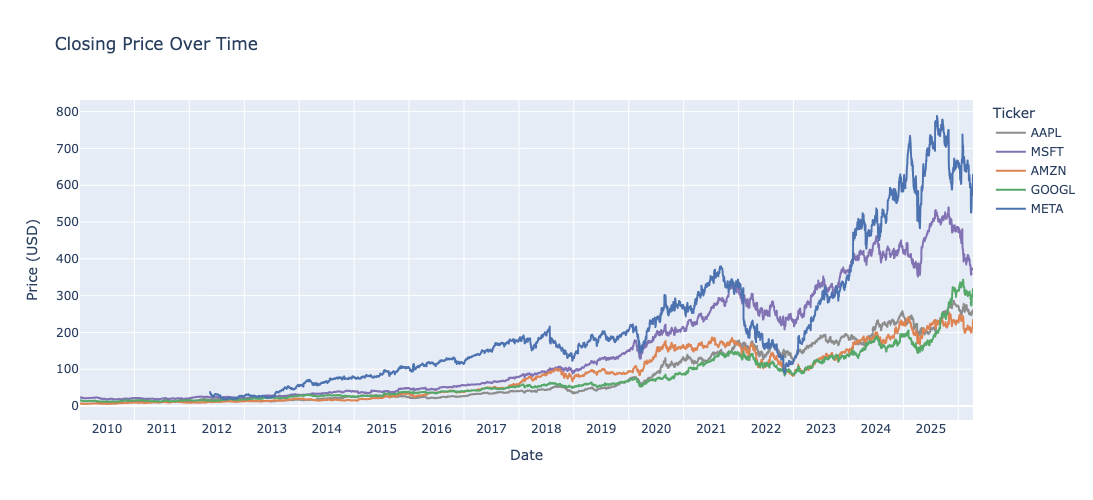

In [6]:
fig = px.line(
    stocks,
    x="Date",
    y="Close",
    color="Ticker",
    color_discrete_map=stock_colors,
    title="Closing Price Over Time",
    labels={"Close": "Price (USD)"},
    hover_data={"Date": "|%B %d, %Y"},
    width=1000,
    height=500
)

fig.update_xaxes(
    dtick="M12",
    tickformat="%Y",
    ticklabelmode="period"
)

fig.show()

It looks like a general upside trend. Around 2021 we can see a short downward direction until the end of 2022, this may be the effects of the Corona virus, the rapid rise in Interest Rates to fight Inflation and the beginning of the war in Ukraine.

To take a closer look into the underlying structures, we are doing seasonal decomposition, which breaks the series into trend, seasonal, and residual components.

### Seasonal decomposition

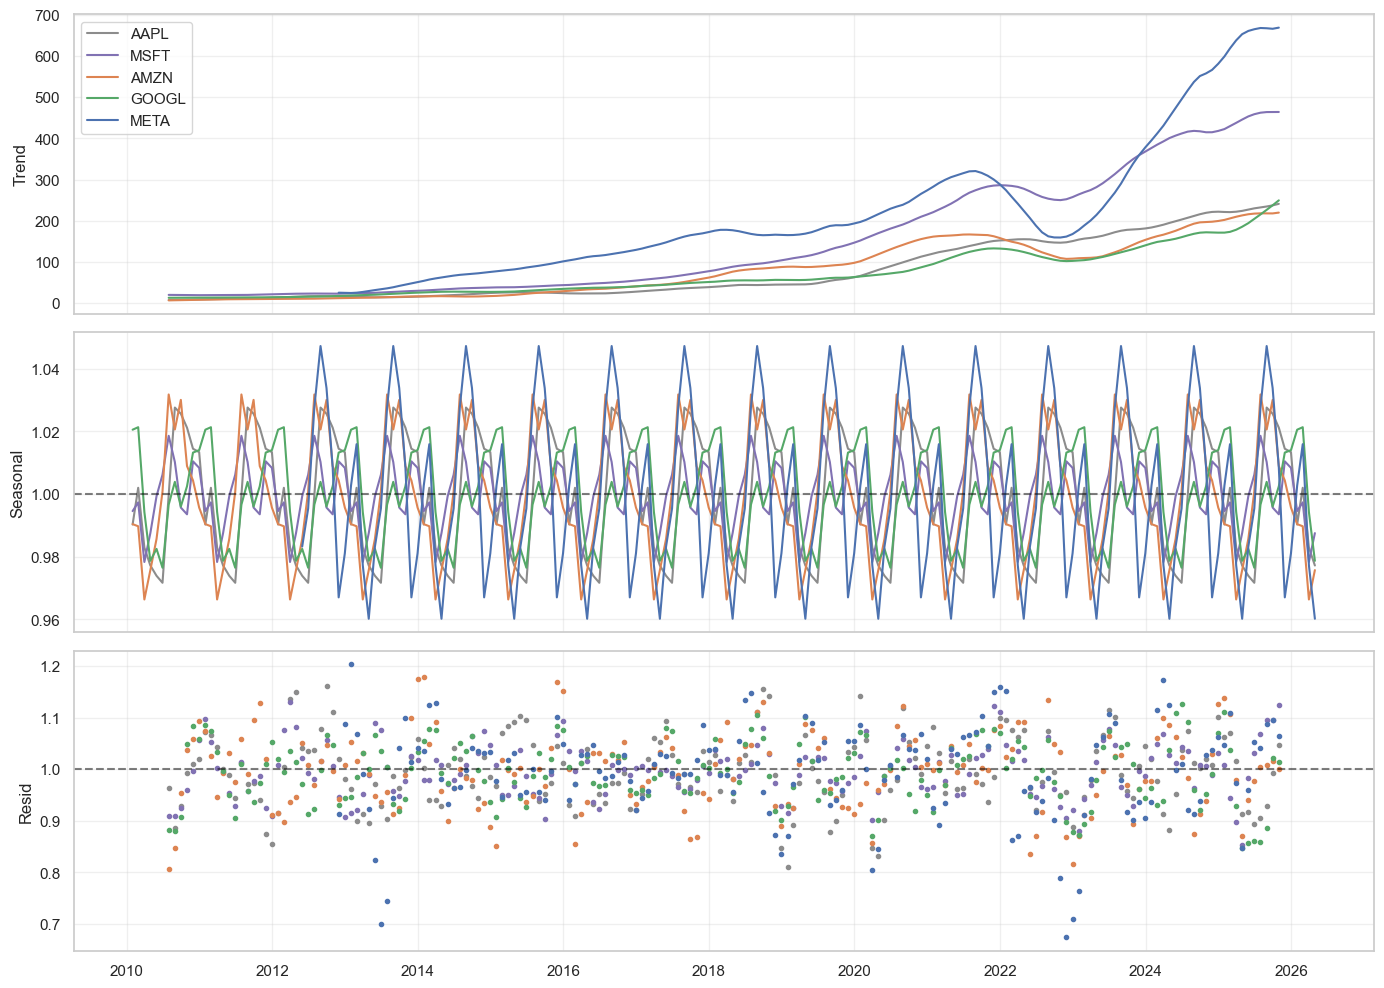

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ticker in ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]:
    monthly = stocks[stocks["Ticker"] == ticker].set_index("Date")["Close"].resample("ME").mean().dropna()
    dec = seasonal_decompose(monthly, model="multiplicative", period=12)

    c = stock_colors[ticker]

    axes[0].plot(dec.trend, label=ticker, color=c)
    axes[1].plot(dec.seasonal, color=c)
    axes[2].plot(dec.resid.index, dec.resid, 'o', markersize=3, color=c)

for ax, name in zip(axes, ["Trend", "Seasonal", "Resid"]):
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[1].axhline(1.0, color='black', linestyle='--', alpha=0.5)
axes[2].axhline(1.0, color='black', linestyle='--', alpha=0.5)
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

The Trend panel highlights a decade of massive overall growth, with Microsoft and Meta recently pulling ahead and a synchronized market dip clearly visible around 2022. 

The Seasonal section reveals that while each stock experiences predictable annual swings of roughly $\pm$4%, their cycles peak at different times depending on their specific business rhythms, such as release schedules. Finally, while the trend explains the long-term macro movements, the broadly dispersed points in the Residual plot indicate that significant volatility remains. Rather than being tightly clustered, these residuals frequently fluctuate by up to $\pm$20%, illustrating that unpredictable market noise and sudden historical shocks, such as the early 2020 market crash or stock-specific earnings reporting consistently overpower the underlying seasonal patterns.

### Smoothing and Noise Reduction

Smoothing techniques help highlight long-term trends by reducing short-term fluctuations. We overlay 30-day and 90-day moving averages on each stock's Close — the 30-day tracks shorter-term momentum, the 90-day smooths over quarterly swings.

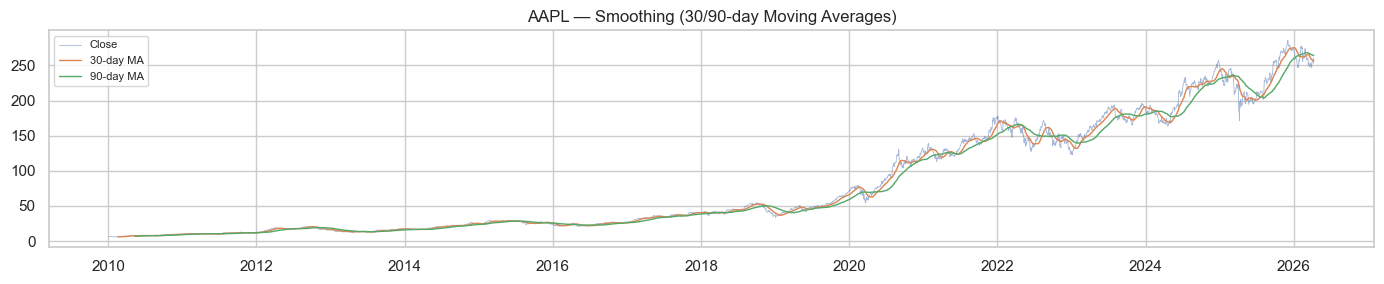

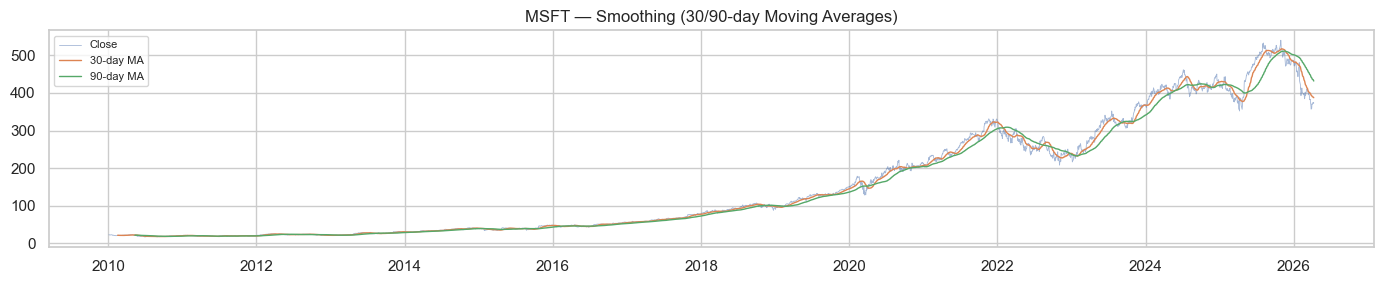

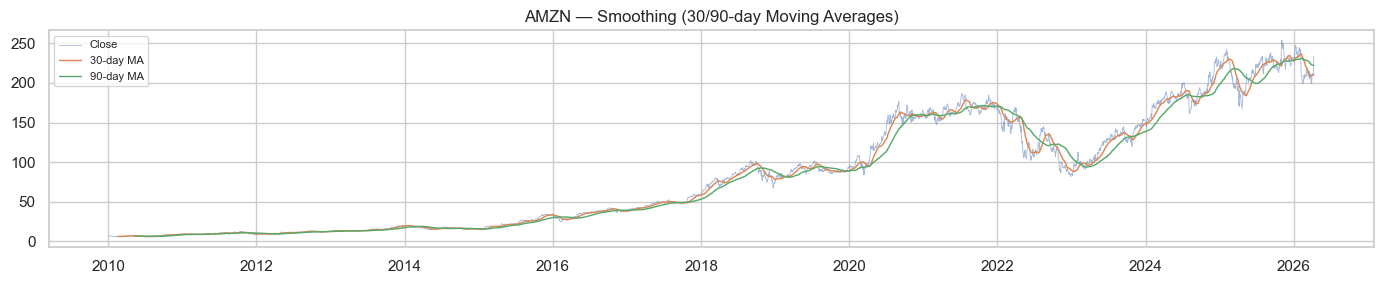

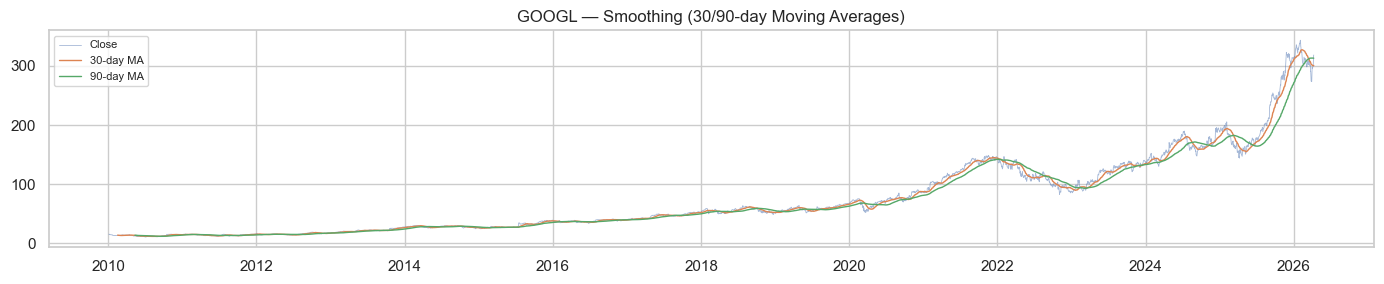

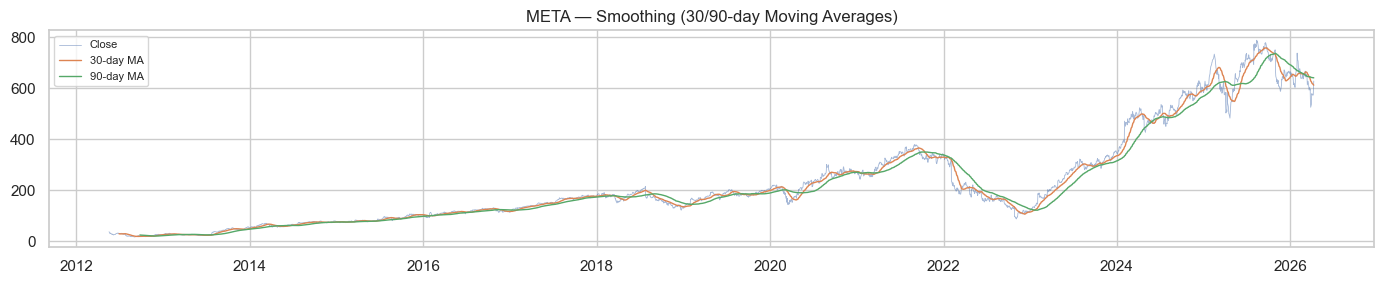

In [8]:
for ticker in tickers:
    sub = stocks[stocks["Ticker"] == ticker].set_index("Date")["Close"]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(sub.index, sub, label="Close", linewidth=0.6, alpha=0.5)
    ax.plot(sub.index, sub.rolling(30).mean(), label="30-day MA", linewidth=1)
    ax.plot(sub.index, sub.rolling(90).mean(), label="90-day MA", linewidth=1)
    ax.set_title(f"{ticker} — Smoothing (30/90-day Moving Averages)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

The 30-day moving average tracks short-term momentum and still wiggles with every few-week swing, while the 90-day MA smooths over roughly a quarter of trading and makes the broader direction easier to read. On every ticker both smoothed lines confirm what the raw plot already suggested: a decade long upward drift interrupted by a synchronized 2022 drawdown and a subsequent recovery.

Short MA crossing below long MA (the so called "death cross") and back above (the so called "golden cross") are classic trend-shift signals: both are clearly visible around March 2020 (COVID) and again in late 2022 / early 2023 (bottoming after the rate-hike shock).

For our forecasting work this confirms that any candidate model has to be **trend-aware** in some way. Allthough we are not predicting the raw price of a stock directly, we are rather focusing on the daily returns, which we're going to take a closer look in the next section.

### Daily Returns

Another important thing we're going to look at is the daily returns. A stock's daily return is the percentual change in price over a single day. We calculate it by subtracting the difference between the stock's closing price on one day and its closing price the day before, dividing the result by the closing of the day before, and multiplying it by 100.

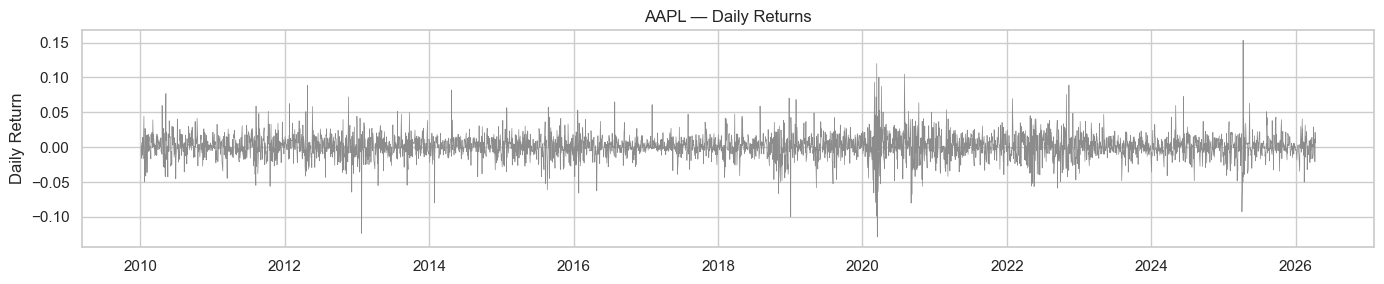

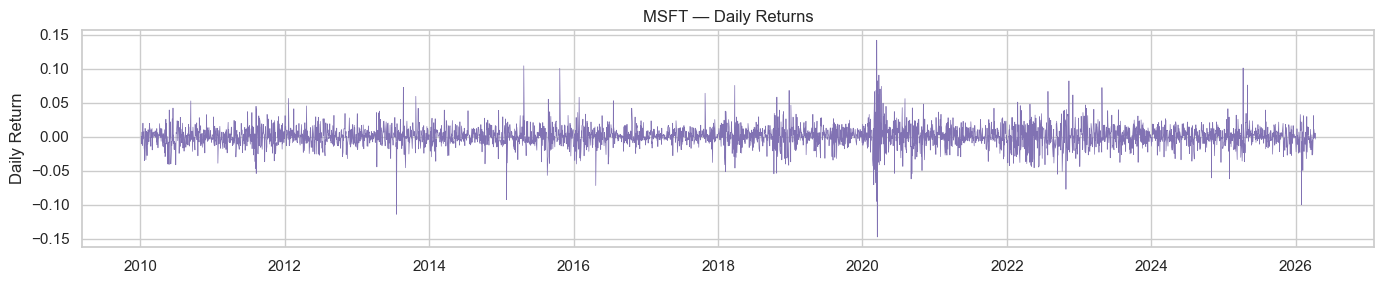

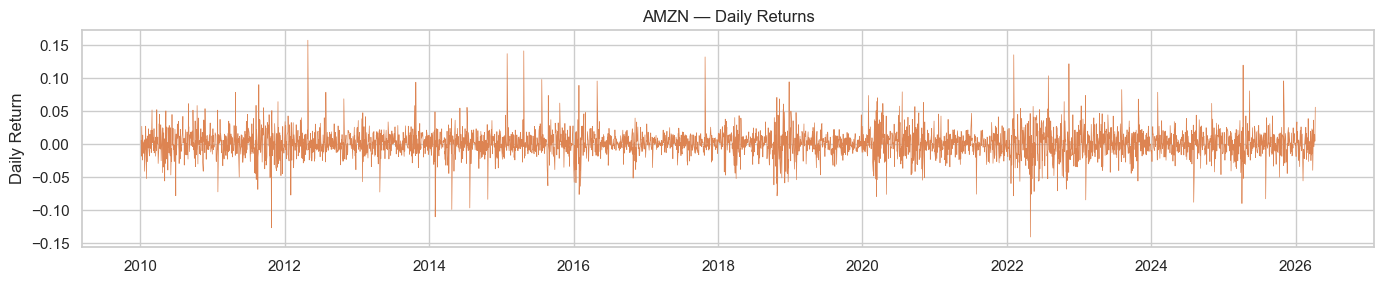

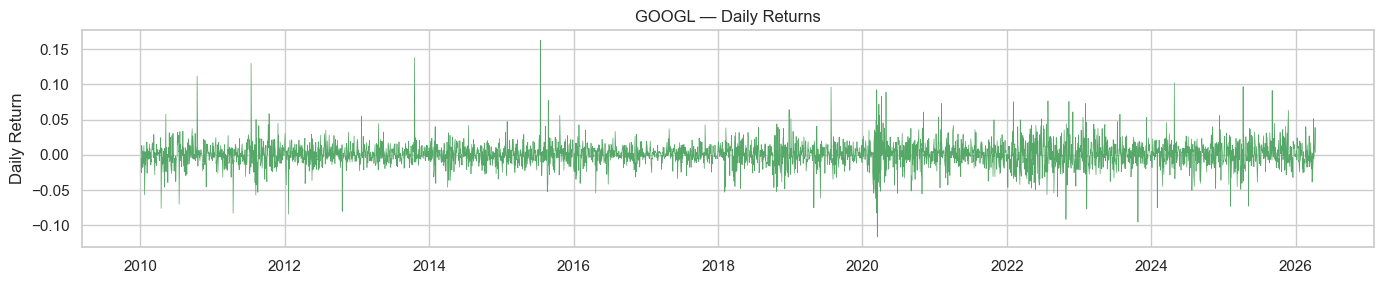

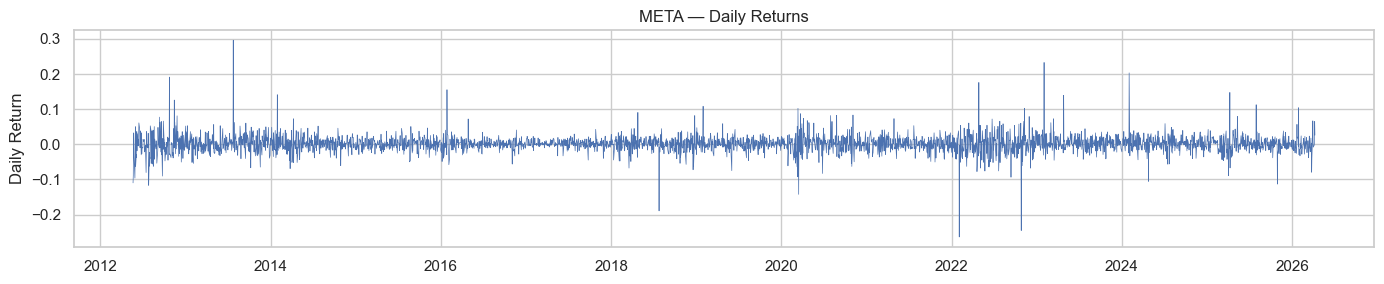

In [9]:
stocks["Daily_Return"] = stocks.groupby("Ticker")["Close"].pct_change()

for ticker in tickers:
    subset = stocks[stocks["Ticker"] == ticker]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(subset["Date"], subset["Daily_Return"], linewidth=0.5, color=stock_colors[ticker])
    ax.set_title(f"{ticker} — Daily Returns")
    ax.set_ylabel("Daily Return")
    plt.tight_layout()
    plt.show()

Daily returns hover around zero but with obvious **volatility clustering**: quiet stretches of ±1–2% days interrupted by bursts where the series swings ±5–10%. The biggest clusters line up with known market events: the March 2020 COVID crash is visible simultaneously across all five tickers, the 2022 rate-hike / Ukraine shock produces a second fat band, and the occasional company-specific outliers stand out (e.g. quarterly earnings).

Importantly, the series itself shows **no visible trend** — the mean level stays near zero throughout. That's exactly what the ADF test later confirms statistically: daily returns are stationary even though the underlying Close prices are not. This is why we're going to model on returns rather than raw prices later.

### Distribution of Daily Returns

Looking at the distribution of daily returns is valuable for identifying patterns such as the typical range of moves an asset makes, indicating its level of stability and volatility.

Checking skewness and kurtosis helps understand whether returns follow a normal distribution: important for statistical inference later, since many classical tests (z-tests, t-tests) assume normality. Any forecast that produces prediction intervals from a normal fit will under-cover extreme days if the true distribution is fat-tailed, and p-values from parametric tests can be misleading when skew or kurtosis are far from their Gaussian values.

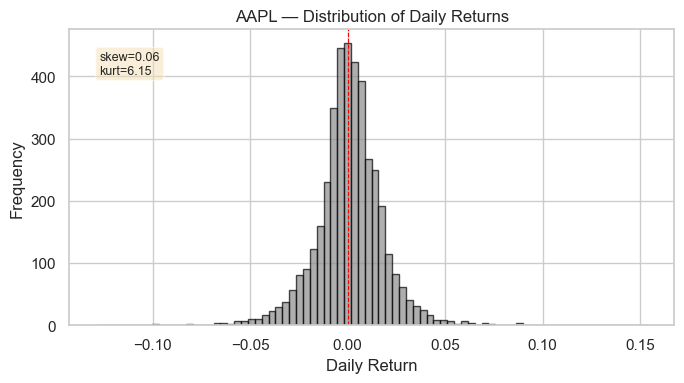

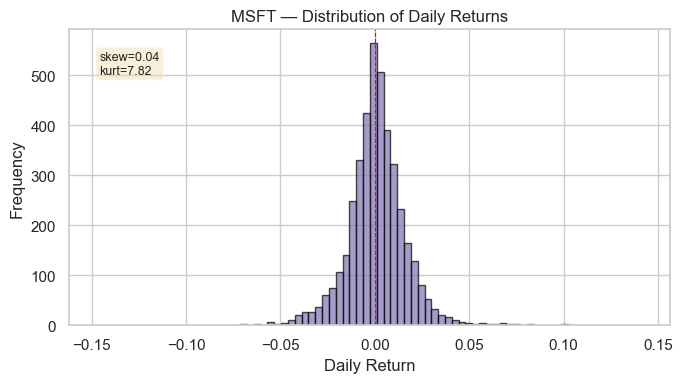

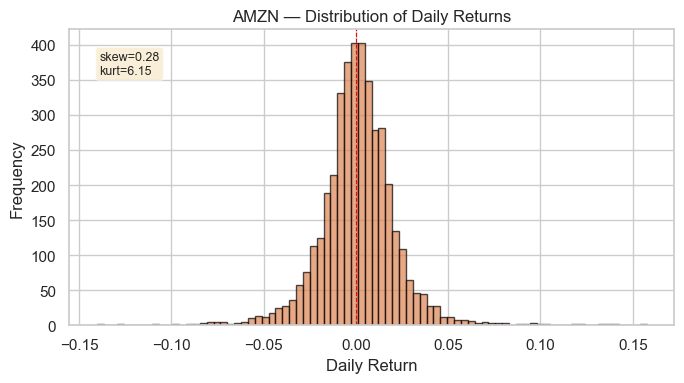

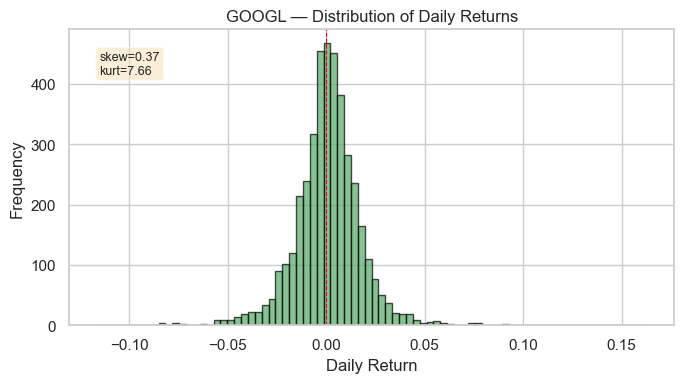

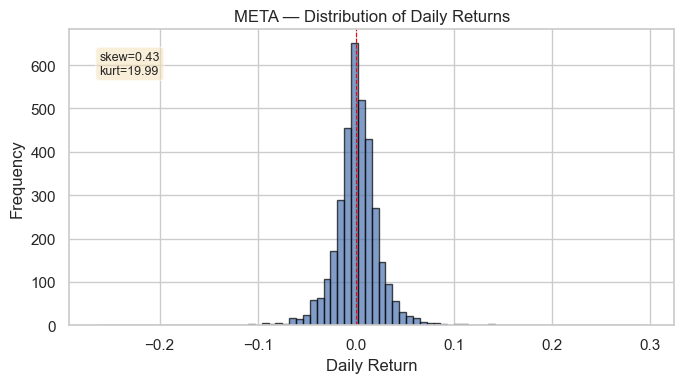

In [10]:
for ticker in tickers:
    subset = stocks[stocks["Ticker"] == ticker]["Daily_Return"].dropna()
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(subset, bins=80, color=stock_colors[ticker], edgecolor="black", alpha=0.7)

    ax.axvline(0, color="red", linestyle="--", linewidth=0.8)
    ax.set_title(f"{ticker} — Distribution of Daily Returns")
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Frequency")

    ax.annotate(
        f"skew={subset.skew():.2f}\nkurt={subset.kurtosis():.2f}",
        xy=(0.05, 0.85), xycoords="axes fraction", fontsize=9,
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()

We see that all five distributions are roughly bell-shaped and centered near zero, but with two systematic departures from normality:

- **Mild-to-moderate positive skew** (~0.04 for AAPL/MSFT, 0.28–0.43 for AMZN/GOOGL/META). A normal distribution has skew = 0; our values mean the right tail is slightly heavier than the left: positive-outlier days are relatively more common than negative-outlier days for the Google/Amazon/Meta trio.
- **Strong excess kurtosis everywhere**: AAPL ~ 6.2, MSFT ~ 7.8, AMZN ~ 6.2, GOOGL ~ 7.7, META ~ 20.0. A normal has excess kurtosis 0; our values are all well above that, and META is extreme.

This means the bell-curve approximation **under-states the risk of extreme moves**.

This means: For the hypothesis tests below we default to non-parametric, rank-based tests (Mann-Whitney U for two groups, Kruskal-Wallis for more than two) rather than t-tests / z-tests that assume normality. These work on ranks instead of means, so they're unaffected by fat tails and report median-based comparisons.

### Correlations Between Stocks

We are also briefly checking how daily returns correlate across stocks. Since those are all tech stocks and in most of the top fonds: e.g. Nasdaq, we may observe the following pattern: Highly correlated stocks move together.

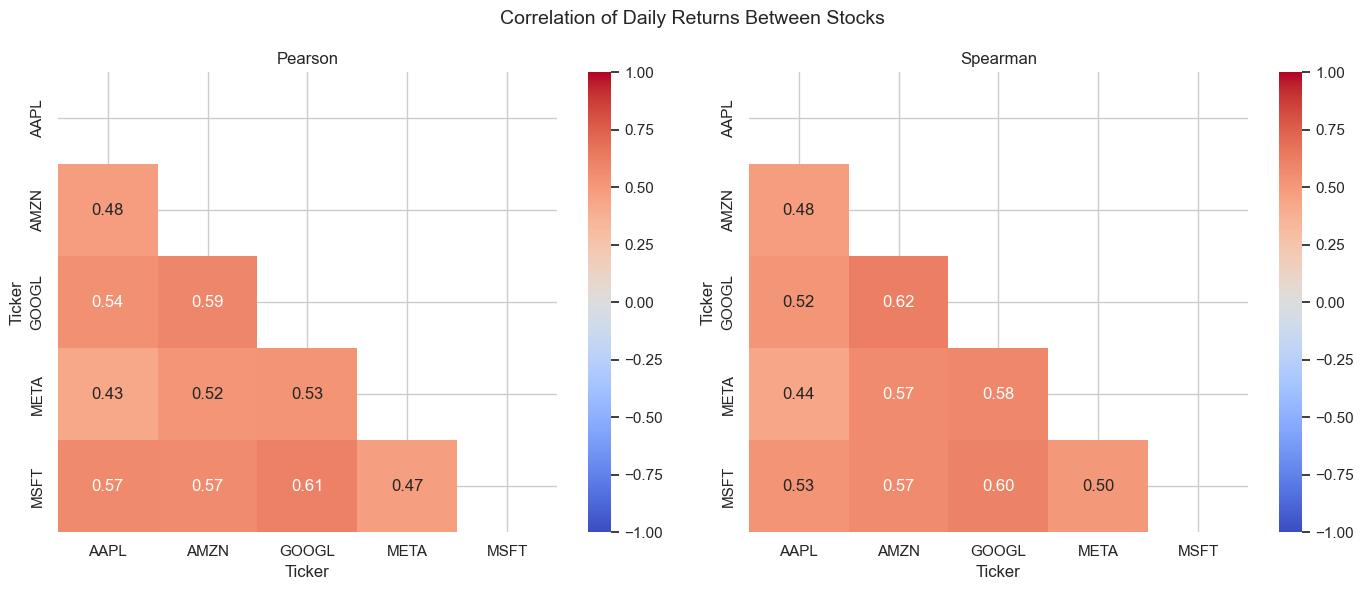

In [11]:
returns_pivot = stocks.pivot(index="Date", columns="Ticker", values="Daily_Return")

pearson = returns_pivot.corr(method="pearson")
spearman = returns_pivot.corr(method="spearman")
mask = np.triu(np.ones_like(pearson, dtype=bool))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(pearson, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Pearson")
sns.heatmap(spearman, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Spearman")
fig.suptitle("Correlation of Daily Returns Between Stocks", fontsize=14)
plt.tight_layout()
plt.show()

We can clearly see that basically all correlations are at least moderate positive correlated (Pearson: r > 0.43) and generally the gap between spearman and pearson is quite low, meaning those correlations are rather linear.

### Stationarity

Checking for Stationarity. Many forecasting models, like ARIMA, assume that the time series, specifically the metric we are looking at, is stationary. We are statistically testing what we observed above using the Augmented Dickey-Fuller (ADF) test.

In [12]:
for ticker in tickers:
    sub = stocks[stocks["Ticker"] == ticker].dropna(subset=["Daily_Return"])
    p_close = adfuller(sub["Close"])[1]
    p_ret = adfuller(sub["Daily_Return"])[1]
    print(f"{ticker}:  Close p={p_close:.3f}; Daily Returns p={p_ret:.2f}")

AAPL:  Close p=0.993; Daily Returns p=0.00
MSFT:  Close p=0.940; Daily Returns p=0.00
AMZN:  Close p=0.969; Daily Returns p=0.00
GOOGL:  Close p=0.999; Daily Returns p=0.00
META:  Close p=0.940; Daily Returns p=0.00


**Close prices (p ~ 0.94–0.99):** far above 0.05, so we fail to reject H0, Close prices are **non-stationary**. Intuitively: today's price depends on how much it has drifted up since 2010; the mean and variance are not constant over time. This is what we expected from what we have observed above: stock prices trend upward over long horizons.

**Daily Returns (p ~ 0):** essentially zero, so we reject H0, returns are **stationary**. Also what we observed above, yet now statistically significant.

## Statistical Inference

**Target population**: daily returns generated by our five tech stocks (AAPL, MSFT, AMZN, GOOGL, META).

We're going to iteratively raise and test hypotheses.

Since our previous checks showed that our data is skewed and not normally distributed, the mean is a misleading metric. Therefore, we use the non-parametric **Mann-Whitney U** test to compare the rank distributions of two groups, which is best represented practically by the **median**: we therefore are going to use this metric to construct the confidence intervals.

We now test whether some of the tendencies observed in EDA are statistically significant. We use Mann-Whitney U tests for comparing return distributions between **two** groups (since returns are not normally distributed) and **Kruskal-Wallis H-test** for comparisons across **more than two** groups. A parametric **t-test** would only be appropriate when data are approximately normal (or the sample is large *and* roughly symmetric so the CLT carries the mean), which is not our situation: kurtosis between 6 and 20 is very far from a Gaussian, so the mean is a noisy summary and t-test p-values would be unreliable.

To be completely rigorous, we would test for normality within each group separately (e.g. via Shapiro-Wilk). However, since stock daily returns are inherently fat-tailed and our overall return distribution already showed clear non-normality, subgroups of the same variable will not suddenly become normal. Additionally, with sample sizes of thousands per group, formal normality tests like Shapiro-Wilk become overly sensitive and reject normality for even trivial deviations. Using non-parametric tests throughout is therefore the safer and more appropriate choice.

### Hypothesis 1: Do the five stocks share the same daily-return distribution?

Null Hypothesis: The distributions - rank positions of daily returns are identical across AAPL, MSFT, AMZN, GOOGL, META.\
Alternative Hypothesis: At least one ticker's distribution differs.\
Significance Level: 0.05\
Test: Kruskal-Wallis H-test

In [13]:
groups = [stocks.loc[stocks["Ticker"] == t, "Daily_Return"].dropna().values
          for t in tickers]

H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H={H:.2f}, p={p:.2f}")

Kruskal-Wallis H-test: H=1.03, p=0.91


Our p-value is above our significance level. Now we know that the effect - the tendency is not statistically significant. This is why there is no Dunn-Bonferroni post-hoc test necessary.

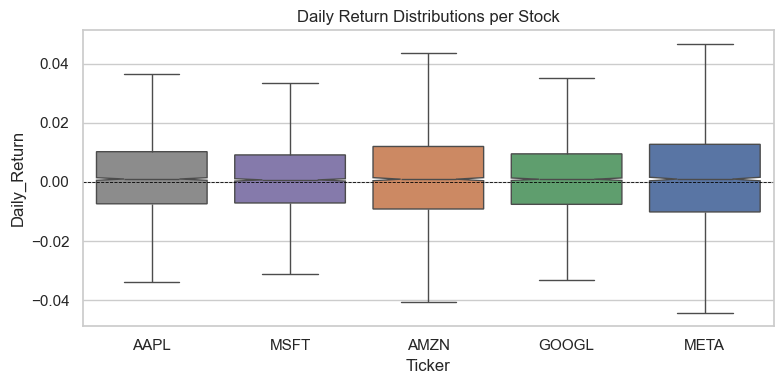

In [14]:
medians = pd.Series({t: stocks.loc[stocks["Ticker"] == t, "Daily_Return"].median()
                     for t in tickers}, name="median_daily_return")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=stocks.dropna(subset=["Daily_Return"]),
    x="Ticker", y="Daily_Return",
    showfliers=False, hue="Ticker", palette=stock_colors,
    legend=False, notch=True, ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=0.6)
ax.set_title("Daily Return Distributions per Stock")
plt.tight_layout()
plt.show()

That's consistent with what we saw in the correlation matrix earlier: these are five highly-correlated stocks in the same sector, and their *central* return distributions behave alike even though their tails don't. We also nicely see that as the median ci intervals are overlapping. Because the global test didn't reject, we skip the pairwise Mann-Whitney follow-ups.

### Hypothesis 2: Did the daily-return differ: before vs. after COVID?

I wanted to take a look at the difference pre and post COVID and took the WHO pandemic declaration (2020-03-11) as differentiation.

Null Hypothesis: For each ticker, the pre- and post-COVID daily-return distributions are identical.\
Alternative Hypothesis: They differ.\
Significance Level: 0.05\
Test: Mann-Whitney U test, per ticker.

In [15]:
cutoff = pd.Timestamp("2020-03-11")
rng = np.random.default_rng(42)

def median_diff(a, b, axis=-1):
    return np.median(b, axis=axis) - np.median(a, axis=axis)

rows = []
for ticker in tickers:
    sub = stocks[stocks["Ticker"] == ticker].dropna(subset=["Daily_Return"])
    pre = sub.loc[sub["Date"] < cutoff, "Daily_Return"].values
    post = sub.loc[sub["Date"] >= cutoff, "Daily_Return"].values

    U, p = stats.mannwhitneyu(pre, post, alternative="two-sided")
    boot = stats.bootstrap((pre, post), median_diff, confidence_level=0.95,
                           n_resamples=2000, random_state=rng)
    ci_lo, ci_hi = boot.confidence_interval

    rows.append({
        "Stock": ticker,
        "median_pre": np.median(pre),
        "median_post": np.median(post),
        "median_diff": np.median(post) - np.median(pre),
        "CI_low": ci_lo, "CI_high": ci_hi,
        "p_value": p
    })

h2 = pd.DataFrame(rows).set_index("Stock")
print(h2[["median_pre", "median_post", "median_diff", "CI_low", "CI_high", "p_value"]]
      .round({"median_pre": 5, "median_post": 5, "median_diff": 5,
              "CI_low": 5, "CI_high": 5, "p_value": 4}))

       median_pre  median_post  median_diff   CI_low  CI_high  p_value
Stock                                                                 
AAPL      0.00092      0.00114      0.00021 -0.00078  0.00129   0.8810
MSFT      0.00065      0.00078      0.00013 -0.00083  0.00095   0.9105
AMZN      0.00097      0.00078     -0.00019 -0.00129  0.00097   0.5318
GOOGL     0.00056      0.00166      0.00109  0.00005  0.00250   0.1829
META      0.00102      0.00091     -0.00011 -0.00170  0.00109   0.9903


We fail to reject the Nullhypothesis for all five stocks.

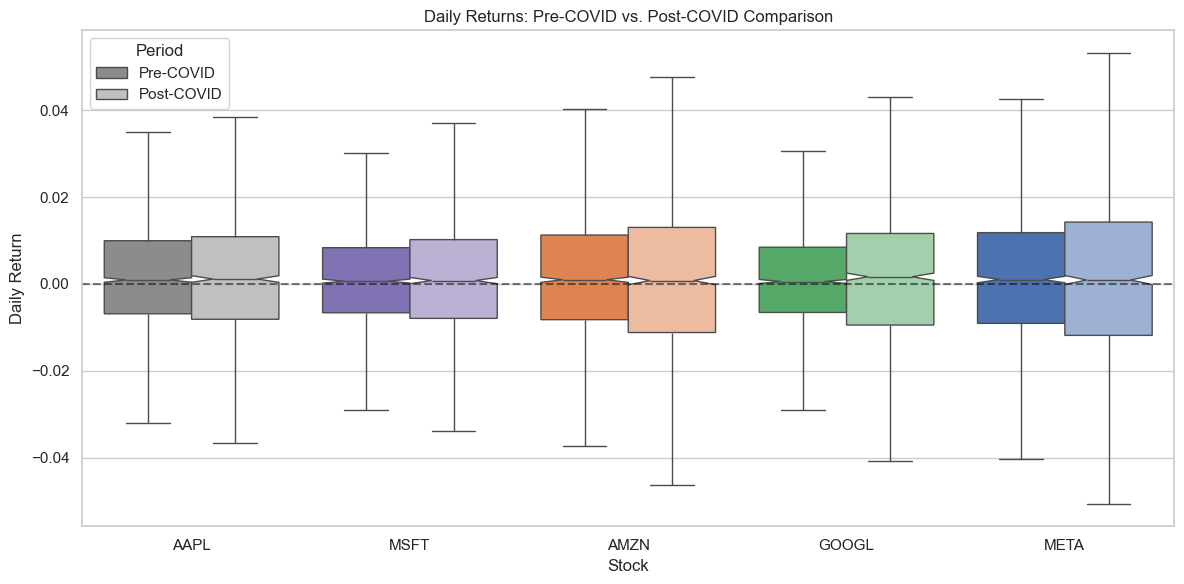

In [16]:
import matplotlib.colors as mcolors
def lighten_color(hex_color, amount=0.45):
    rgb = mcolors.to_rgb(hex_color)
    return mcolors.to_hex([min(1, x + (1 - x) * amount) for x in rgb])
    
plot_df = stocks.dropna(subset=["Daily_Return"]).copy()
plot_df["Period"] = np.where(plot_df["Date"] < cutoff, "Pre-COVID", "Post-COVID")

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=plot_df,
    x="Ticker",
    y="Daily_Return",
    hue="Period",
    showfliers=False,
    notch=True
)

n_tickers = len(tickers)
for i, ticker in enumerate(tickers):
    base_color = stock_colors[ticker]
    light_color = lighten_color(base_color)
    ax.patches[i].set_facecolor(base_color)
    ax.patches[i + n_tickers].set_facecolor(light_color)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Daily Returns: Pre-COVID vs. Post-COVID Comparison")
plt.ylabel("Daily Return")
plt.xlabel("Stock")

handles, labels = ax.get_legend_handles_labels()
handles[0].set_facecolor(stock_colors["AAPL"])
handles[1].set_facecolor(lighten_color(stock_colors["AAPL"]))

plt.legend(handles[0:2], ['Pre-COVID', 'Post-COVID'], title="Period")

plt.tight_layout()
plt.show()

### Hypothesis 3: Do Monday daily returns differ from Friday daily returns? (the "weekend effect")

Null Hypothesis: For each ticker, the distributions of Monday and Friday daily returns are identical.\
Alternative Hypothesis: They differ.\
Significance Level: 0.05\
Test: Mann-Whitney U test

The so-called *weekend effect* (or *Monday effect*): that markets behave differently around the weekend boundary. Since exchanges close on weekends, Monday returns represent a 72-hour 'news jump' compared to Friday’s standard 24-hour cycle. Historically, this structural gap created the 'weekend effect,' where Mondays absorbed accumulated weekend news, often leading to a downward 'dip.' Due to modern market efficiency, this anomaly is likely minimized. Our EDA didn't speak directly to it, so this is a fresh test rather than a confirmation of something we already saw.

In [17]:
rng = np.random.default_rng(42)

def median_diff(a, b, axis=-1):
    return np.median(b, axis=axis) - np.median(a, axis=axis)

rows = []
for ticker in tickers:
    sub = stocks[stocks["Ticker"] == ticker].dropna(subset=["Daily_Return"]).copy()
    sub["weekday"] = pd.to_datetime(sub["Date"]).dt.day_name()
    mon = sub.loc[sub["weekday"] == "Monday", "Daily_Return"].values
    fri = sub.loc[sub["weekday"] == "Friday", "Daily_Return"].values

    U, p = stats.mannwhitneyu(mon, fri, alternative="two-sided")
    boot = stats.bootstrap((mon, fri), median_diff, confidence_level=0.95,
                           n_resamples=2000, random_state=rng)
    ci_lo, ci_hi = boot.confidence_interval

    rows.append({
        "Ticker": ticker,
        "median_mon": np.median(mon),
        "median_fri": np.median(fri),
        "diff_fri_minus_mon": np.median(fri) - np.median(mon),
        "CI_low": ci_lo, "CI_high": ci_hi,
        "p_value": p,
    })

h3 = pd.DataFrame(rows).set_index("Ticker")
print(h3.round({"median_mon": 5, "median_fri": 5, "diff_fri_minus_mon": 5,
                "CI_low": 5, "CI_high": 5, "p_value": 4}))

        median_mon  median_fri  diff_fri_minus_mon   CI_low  CI_high  p_value
Ticker                                                                       
AAPL       0.00377    -0.00038            -0.00415 -0.00582 -0.00252   0.0000
MSFT       0.00082     0.00069            -0.00013 -0.00143  0.00088   0.9744
AMZN       0.00084    -0.00029            -0.00113 -0.00268  0.00088   0.4431
GOOGL      0.00152    -0.00028            -0.00180 -0.00345  0.00008   0.0928
META       0.00176     0.00024            -0.00151 -0.00350  0.00036   0.1307


We see that while we fail to reject the Nullhypothesis for MSFT, AMZN, GOOGL and META, for AAPL we reject the Nullhypothesis and conclude the alternative one. Allthough for Apple there is statistically significant effect, we don't know in which way. This is why we are taking a look at the Boxplots of the compared returns.

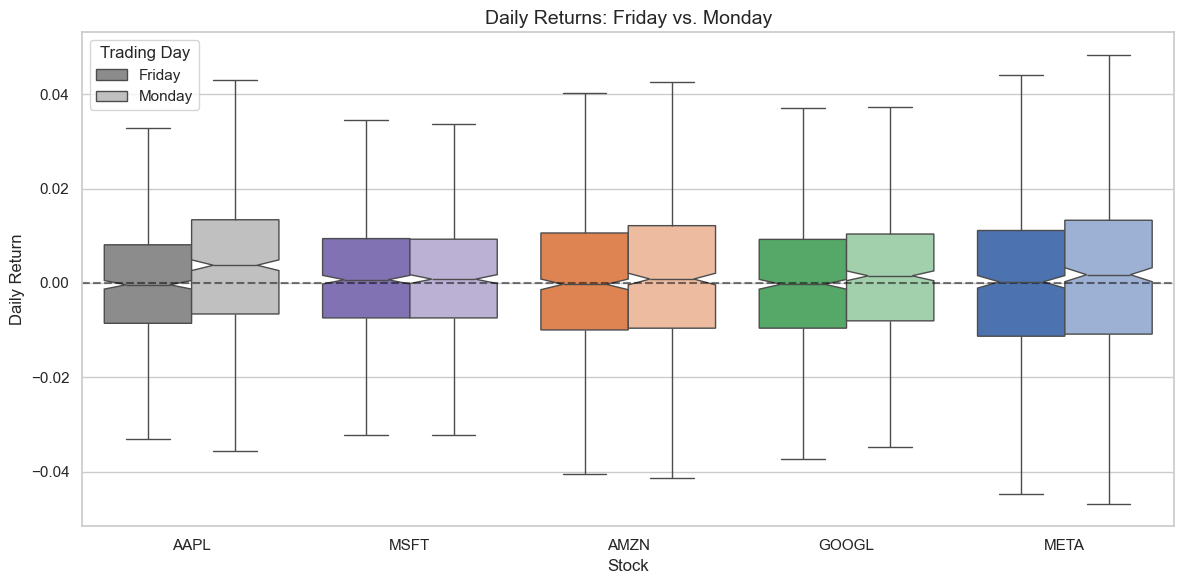

In [18]:
stocks['Day_of_Week'] = stocks['Date'].dt.dayofweek
mon_fri_df = stocks[stocks['Day_of_Week'].isin([0, 4])].dropna(subset=["Daily_Return"]).copy()
mon_fri_df['Day_Name'] = np.where(mon_fri_df['Day_of_Week'] == 0, 'Monday', 'Friday')

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=mon_fri_df,
    x="Ticker",
    y="Daily_Return",
    hue="Day_Name",
    hue_order=['Friday', 'Monday'],
    showfliers=False,
    notch=True,
    width=0.8,
    gap=0
)

n_tickers = len(tickers)
for i, ticker in enumerate(tickers):
    base_color = stock_colors[ticker]
    ax.patches[i].set_facecolor(base_color)               
    ax.patches[i + n_tickers].set_facecolor(lighten_color(base_color)) 

handles, _ = ax.get_legend_handles_labels()
handles[0].set_facecolor(stock_colors["AAPL"])
handles[1].set_facecolor(lighten_color(stock_colors["AAPL"]))
plt.legend(handles, ['Friday', 'Monday'], title="Trading Day")

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Daily Returns: Friday vs. Monday", fontsize=14)
plt.ylabel("Daily Return")
plt.xlabel("Stock")
plt.tight_layout()
plt.show()

## Time-Series Forecasting

Our goal is to build a generic time-series model that is capable of predicting next day stock price based on previous patterns. The model is the same for all stocks and we are evaluating its performance on each stock independently.

Predicting the next day stock price doesn't mean we can simply predict the continuous value of the closing price using standard regression, since price levels differ drastically across our stocks. We therefore try to predict the daily return and convert it back into the absolute price for each stock afterwards.

We are using the following metrics: **Mean Absolute Percentage Error (MAPE)**, **Symmetric Mean Absolute Percentage Error (sMAPE)** and **Forecast Bias**.

With sMAPE being the most important one, since MAPE can be unstable when actual values are close to zero, and sMAPE reduces this issue.

### Preparation

Machine learning models don’t explicitly model time dependencies but can be adapted by framing forecasting as a supervised learning problem. We are therefore creating lagged features and rolling statistics, include time-based features and
split the data chronologically to prevent data leakage.

In [19]:
df = stocks.sort_values(by=["Ticker", "Date"]).copy()
df["Return"] = df.groupby("Ticker")["Close"].pct_change()

df["lag_1"] = df.groupby("Ticker")["Return"].shift(1)
df["lag_2"] = df.groupby("Ticker")["Return"].shift(2)
df["lag_5"] = df.groupby("Ticker")["Return"].shift(5)

rmean_5 = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df["rmean_5_dist"] = df["Close"] / rmean_5 - 1
df["rstd_5"] = df.groupby("Ticker")["Return"].transform(lambda x: x.rolling(5).std())

df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month

df["Target_Return"] = df.groupby("Ticker")["Return"].shift(-1)
df.dropna(inplace=True)

### Split the Data

We are doing a chronological 80/20 split per stock to preserve time-series order and prevent data leakage.

In [20]:
target = "Target_Return"
drop_cols = ["Date", "Target_Return", "Close"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df[target].copy()

is_test = df.groupby("Ticker").cumcount() / df.groupby("Ticker")["Ticker"].transform("count") >= 0.8

X_train, X_test = X[~is_test].copy(), X[is_test].copy()
y_train, y_test = y[~is_test].copy(), y[is_test].copy()

def eval_preds(actual, preds):
    actual = np.asarray(actual, dtype=float)
    preds = np.asarray(preds, dtype=float)
    denominator = (np.abs(actual) + np.abs(preds))
    return {
        "MAPE": mean_absolute_percentage_error(actual, preds),
        "sMAPE": float(np.mean(2 * np.abs(actual - preds) / np.maximum(denominator, 1e-10))),
        "Bias": float(np.mean(preds - actual)),
    }

print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")

Training set: 15,860
Test set: 3,961


### Preprocessing

In [21]:
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

### Baseline models

In [22]:
ml_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GBM": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for ticker in tickers:
    idx_t = X_train[X_train["Ticker"] == ticker].index
    tr_ret_all = y_train.loc[idx_t].values
    price_today_all = df.loc[idx_t, "Close"].values

    for tr_idx, va_idx in tscv.split(tr_ret_all):
        tr_ret, va_ret = tr_ret_all[tr_idx], tr_ret_all[va_idx]
        va_price_today = price_today_all[va_idx]
        va_actual_price = va_price_today * (1 + va_ret)

        cv_rows.append({"Model": "Naive", "Ticker": ticker, **eval_preds(va_actual_price, va_price_today)})

        try:
            pred_ret_ses = SimpleExpSmoothing(tr_ret).fit().forecast(len(va_ret))
            cv_rows.append({"Model": "SES", "Ticker": ticker, **eval_preds(va_actual_price, va_price_today * (1 + pred_ret_ses))})
        except: pass

        try:
            pred_ret_holt = Holt(tr_ret).fit().forecast(len(va_ret))
            cv_rows.append({"Model": "Holt", "Ticker": ticker, **eval_preds(va_actual_price, va_price_today * (1 + pred_ret_holt))})
        except: pass

        try:
            pred_ret_arima = ARIMA(tr_ret, order=(1, 0, 1)).fit().forecast(len(va_ret))
            cv_rows.append({"Model": "ARIMA", "Ticker": ticker, **eval_preds(va_actual_price, va_price_today * (1 + pred_ret_arima))})
        except: pass

all_train_dates = np.array(sorted(df.loc[X_train.index, "Date"].unique()))

for tr_date_idx, va_date_idx in tscv.split(all_train_dates):
    tr_dates = set(all_train_dates[tr_date_idx])
    va_dates = set(all_train_dates[va_date_idx])

    tr_idx = X_train[df.loc[X_train.index, "Date"].isin(tr_dates)].index
    va_idx = X_train[df.loc[X_train.index, "Date"].isin(va_dates)].index

    X_tr_cv, y_tr_cv = X_train.loc[tr_idx], y_train.loc[tr_idx]

    for name, model in ml_models.items():
        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_tr_cv, y_tr_cv)

        for ticker in tickers:
            t_va_idx = va_idx[X_train.loc[va_idx, "Ticker"] == ticker]
            if len(t_va_idx) == 0: continue

            va_price_today = df.loc[t_va_idx, "Close"].values
            va_actual_price = va_price_today * (1 + y_train.loc[t_va_idx].values)

            pred_ret = pipe.predict(X_train.loc[t_va_idx])
            
            cv_rows.append({
                "Model": name, 
                "Ticker": ticker, 
                **eval_preds(va_actual_price, va_price_today * (1 + pred_ret))
            })

cv_df = pd.DataFrame(cv_rows)
cv_summary = cv_df.groupby(["Model", "Ticker"])[["MAPE", "sMAPE", "Bias"]].mean().round(4)
display(cv_summary)

MAPE   sMAPE     Bias
Model            Ticker                         
ARIMA            AAPL    0.0129  0.0128   0.0290
                 AMZN    0.0140  0.0140   0.0655
                 GOOGL   0.0115  0.0115   0.0136
                 META    0.0153  0.0152   0.1626
                 MSFT    0.0114  0.0114   0.0151
DecisionTree     AAPL    0.0220  0.0218   0.1346
                 AMZN    0.0216  0.0216   0.0060
                 GOOGL   0.0185  0.0184   0.0986
                 META    0.0384  0.0401  -4.5073
                 MSFT    0.0220  0.0224  -1.2446
GBM              AAPL    0.0130  0.0130   0.0163
                 AMZN    0.0145  0.0145   0.0476
                 GOOGL   0.0118  0.0118   0.0359
                 META    0.0297  0.0310  -3.9486
                 MSFT    0.0152  0.0155  -0.9744
Holt             AAPL    0.2438  0.2468   5.4949
                 AMZN    0.1509  0.1438   5.3979
                 GOOGL   0.1209  0.1132   6.0912
                 META    0.5205  0.3396  20.7286
                 MSFT    0.0955  0.0873  12.7571
KNN              AAPL    0.0144  0.0144   0.0241
                 AMZN    0.0156  0.0156   0.0297
                 GOOGL   0.0129  0.0129   0.0231
                 META    0.0181  0.0181  -0.3864
                 MSFT    0.0128  0.0128  -0.0565
Lasso            AAPL    0.0129  0.0129   0.0256
                 AMZN    0.0141  0.0141   0.0552
                 GOOGL   0.0117  0.0117   0.0376
                 META    0.0164  0.0164   0.0599
                 MSFT    0.0116  0.0116   0.0517
LinearRegression AAPL    0.0130  0.0130  -0.0139
                 AMZN    0.0142  0.0142   0.0017
                 GOOGL   0.0118  0.0118  -0.0213
                 META    0.0173  0.0173  -0.1999
                 MSFT    0.0117  0.0117  -0.1236
Naive            AAPL    0.0128  0.0128  -0.0388
                 AMZN    0.0140  0.0140  -0.0272
                 GOOGL   0.0115  0.0115  -0.0258
                 META    0.0153  0.0152  -0.0953
                 MSFT    0.0114  0.0114  -0.0701
RandomForest     AAPL    0.0132  0.0132   0.0050
                 AMZN    0.0147  0.0147   0.0400
                 GOOGL   0.0121  0.0121   0.0346
                 META    0.0252  0.0258  -2.6674
                 MSFT    0.0143  0.0144  -0.6937
Ridge            AAPL    0.0130  0.0129  -0.0122
                 AMZN    0.0142  0.0142   0.0039
                 GOOGL   0.0118  0.0118  -0.0216
                 META    0.0168  0.0168  -0.1775
                 MSFT    0.0117  0.0117  -0.1235
SES              AAPL    0.0132  0.0131   0.1000
                 AMZN    0.0140  0.0140   0.1102
                 GOOGL   0.0115  0.0115   0.0328
                 META    0.0153  0.0152   0.0576
                 MSFT    0.0115  0.0115   0.1081

Now we are taking the mean each, looking at the sMAPE to decide, which model we're going to tune further.

In [23]:
cv_global = cv_summary.groupby("Model")[["MAPE", "sMAPE", "Bias"]].mean().sort_values("sMAPE")
display(cv_global)

,MAPE,sMAPE,Bias
Model,,,
ARIMA,0.01302,0.01298,0.05716
Naive,0.01300,0.01298,-0.05144
SES,0.01310,0.01306,0.08174
Lasso,0.01334,0.01334,0.04600
Ridge,0.01350,0.01348,-0.06618
LinearRegression,0.01360,0.01360,-0.07140
KNN,0.01476,0.01476,-0.07320
RandomForest,0.01590,0.01604,-0.65630
GBM,0.01684,0.01716,-0.96464


ARIMA performs best so far, this is why we are going to tune it further. Additionally we are also tuning Lasso, as its the best performing Machine Learning model.

### Tuning the best model

In [24]:
def objective_arima(trial):
    p = trial.suggest_int("p", 0, 3)
    q = trial.suggest_int("q", 0, 3)
    cfg = (p, 0, q)
    
    fold_smapes = []
    for ticker in tickers:
        idx_t = X_train[X_train["Ticker"] == ticker].index
        tr_ret_all = y_train.loc[idx_t].values
        price_today_all = df.loc[idx_t, "Close"].values

        for tr_idx, va_idx in tscv.split(tr_ret_all):
            tr_ret, va_ret = tr_ret_all[tr_idx], tr_ret_all[va_idx]
            va_price_today = price_today_all[va_idx]
            va_actual_price = va_price_today * (1 + va_ret)

            try:
                model_fit = ARIMA(tr_ret, order=cfg).fit()
                pred_ret = model_fit.forecast(len(va_ret))
                pred_price = va_price_today * (1 + pred_ret)
                res = eval_preds(va_actual_price, pred_price)
                fold_smapes.append(res["sMAPE"])
            except:
                continue
                
    return float(np.mean(fold_smapes)) if fold_smapes else np.inf

study_arima = optuna.create_study(direction="minimize")
study_arima.optimize(objective_arima, n_trials=15)
best_cfg = (study_arima.best_params["p"], 0, study_arima.best_params["q"])

all_train_dates = np.array(sorted(df.loc[X_train.index, "Date"].unique()))

def objective_lasso(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1.0, log=True)
    ml_fold_smapes = []
    
    pipe = Pipeline([("prep", preprocessor), ("model", Lasso(alpha=alpha, random_state=42))])
    
    for tr_date_idx, va_date_idx in tscv.split(all_train_dates):
        tr_dates = set(all_train_dates[tr_date_idx])
        va_dates = set(all_train_dates[va_date_idx])

        tr_idx = X_train[df.loc[X_train.index, "Date"].isin(tr_dates)].index
        va_idx = X_train[df.loc[X_train.index, "Date"].isin(va_dates)].index

        pipe.fit(X_train.loc[tr_idx], y_train.loc[tr_idx])

        for ticker in tickers:
            t_va_idx = va_idx[X_train.loc[va_idx, "Ticker"] == ticker]
            if len(t_va_idx) == 0: continue

            va_price_today = df.loc[t_va_idx, "Close"].values
            va_actual_price = va_price_today * (1 + y_train.loc[t_va_idx].values)

            pred_ret = pipe.predict(X_train.loc[t_va_idx])
            pred_price = va_price_today * (1 + pred_ret)
            
            res = eval_preds(va_actual_price, pred_price)
            ml_fold_smapes.append(res["sMAPE"])
            
    return float(np.mean(ml_fold_smapes)) if ml_fold_smapes else np.inf

study_lasso = optuna.create_study(direction="minimize")
study_lasso.optimize(objective_lasso, n_trials=25)
best_lasso_alpha = study_lasso.best_params["alpha"]

tuned_cv_rows = []

for ticker in tickers:
    idx_t = X_train[X_train["Ticker"] == ticker].index
    tr_ret_all = y_train.loc[idx_t].values
    price_today_all = df.loc[idx_t, "Close"].values

    for tr_idx, va_idx in tscv.split(tr_ret_all):
        tr_ret, va_ret = tr_ret_all[tr_idx], tr_ret_all[va_idx]
        va_price_today = price_today_all[va_idx]
        va_actual_price = va_price_today * (1 + va_ret)

        try:
            pred_ret = ARIMA(tr_ret, order=best_cfg).fit().forecast(len(va_ret))
            pred_price = va_price_today * (1 + pred_ret)
            tuned_cv_rows.append({"Model": "ARIMA (Tuned)", "Ticker": ticker, **eval_preds(va_actual_price, pred_price)})
        except:
            pass

pipe_lasso_tuned = Pipeline([("prep", preprocessor), ("model", Lasso(alpha=best_lasso_alpha, random_state=42))])

for tr_date_idx, va_date_idx in tscv.split(all_train_dates):
    tr_dates = set(all_train_dates[tr_date_idx])
    va_dates = set(all_train_dates[va_date_idx])
    tr_idx = X_train[df.loc[X_train.index, "Date"].isin(tr_dates)].index
    va_idx = X_train[df.loc[X_train.index, "Date"].isin(va_dates)].index

    pipe_lasso_tuned.fit(X_train.loc[tr_idx], y_train.loc[tr_idx])

    for ticker in tickers:
        t_va_idx = va_idx[X_train.loc[va_idx, "Ticker"] == ticker]
        if len(t_va_idx) == 0: continue

        va_price_today = df.loc[t_va_idx, "Close"].values
        va_actual_price = va_price_today * (1 + y_train.loc[t_va_idx].values)
        pred_ret = pipe_lasso_tuned.predict(X_train.loc[t_va_idx])
        pred_price = va_price_today * (1 + pred_ret)
        
        tuned_cv_rows.append({"Model": "Lasso (Tuned)", "Ticker": ticker, **eval_preds(va_actual_price, pred_price)})

tuned_cv_df = pd.DataFrame(tuned_cv_rows)
tuned_cv_summary = tuned_cv_df.groupby(["Model", "Ticker"])[["sMAPE", "MAPE", "Bias"]].mean().round(4)
display(tuned_cv_summary)

tuned_cv_global = tuned_cv_summary.groupby("Model")[["sMAPE", "MAPE", "Bias"]].mean().sort_values("sMAPE")
display(tuned_cv_global)

print(f"Best ARIMA Params: {best_cfg}")
print(f"Best Lasso Alpha: {best_lasso_alpha:.3f}")

sMAPE    MAPE    Bias
Model         Ticker                        
ARIMA (Tuned) AAPL    0.0128  0.0129  0.0289
              AMZN    0.0140  0.0140  0.0656
              GOOGL   0.0115  0.0115  0.0135
              META    0.0152  0.0153  0.1624
              MSFT    0.0114  0.0114  0.0151
Lasso (Tuned) AAPL    0.0129  0.0129  0.0256
              AMZN    0.0141  0.0141  0.0552
              GOOGL   0.0117  0.0117  0.0376
              META    0.0164  0.0164  0.0599
              MSFT    0.0116  0.0116  0.0517

,sMAPE,MAPE,Bias
Model,,,
ARIMA (Tuned),0.01298,0.01302,0.0571
Lasso (Tuned),0.01334,0.01334,0.0460


Best ARIMA Params: (0, 0, 0)
Best Lasso Alpha: 0.260


### Evaluation

We evaluate against hold-out test set and baseline comparison, our baseline is the Naïve forecasting model, which is the simplest approach where the forecast for the next time step is just the last observed value.

In [25]:
test_rows = []

pipe_lasso_tuned = Pipeline([("prep", preprocessor), ("model", Lasso(alpha=best_lasso_alpha, random_state=42))])
pipe_lasso_tuned.fit(X_train, y_train)

for ticker in tickers:
    idx_tr = X_train[X_train["Ticker"] == ticker].index
    idx_te = X_test[X_test["Ticker"] == ticker].index

    if len(idx_te) == 0:
        continue

    tr_ret = y_train.loc[idx_tr].values
    te_price_today = df.loc[idx_te, "Close"].values
    te_actual_price = te_price_today * (1 + y_test.loc[idx_te].values)

    pred_price_naive = te_price_today
    test_rows.append({"Model": "Naive Baseline", "Ticker": ticker, **eval_preds(te_actual_price, pred_price_naive)})

    try:
        pred_ret_arima = ARIMA(tr_ret, order=best_cfg).fit().forecast(len(idx_te))
        pred_price_arima = te_price_today * (1 + pred_ret_arima)
        test_rows.append({"Model": "ARIMA (Tuned)", "Ticker": ticker, **eval_preds(te_actual_price, pred_price_arima)})
    except:
        pass

    pred_ret_lasso = pipe_lasso_tuned.predict(X_test.loc[idx_te])
    pred_price_lasso = te_price_today * (1 + pred_ret_lasso)
    test_rows.append({"Model": "Lasso (Tuned)", "Ticker": ticker, **eval_preds(te_actual_price, pred_price_lasso)})

test_df = pd.DataFrame(test_rows).set_index(["Model", "Ticker"]).round(4).sort_values("sMAPE")
display(test_df)

,,MAPE,sMAPE,Bias
Model,Ticker,,,
Naive Baseline,MSFT,0.0107,0.0107,-0.1917
ARIMA (Tuned),MSFT,0.0107,0.0107,0.1351
Lasso (Tuned),MSFT,0.0107,0.0107,0.1817
ARIMA (Tuned),AAPL,0.0109,0.0109,0.0540
Lasso (Tuned),AAPL,0.0109,0.0109,0.0268
Naive Baseline,AAPL,0.0110,0.0110,-0.1684
ARIMA (Tuned),GOOGL,0.0137,0.0137,-0.1661
Lasso (Tuned),GOOGL,0.0137,0.0137,-0.1199
Naive Baseline,GOOGL,0.0138,0.0138,-0.2855


The test set results clearly demonstrate the highly noisy nature of daily financial time series. While the tuned ARIMA and Lasso models only marginally improved the absolute error (sMAPE) compared to the Naive Baseline, their true value lies in the Forecast Bias. The Naive Baseline systematically underestimated prices due to the upward market trend. In contrast, the regularized Lasso model successfully captured this underlying drift, centering the predictions and reducing the bias to near-zero (e.g., from -0.495 to 0.013 for META) without overfitting the noise.

In [26]:
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
y_train_reg = y_train.copy()
y_test_reg = y_test.copy()

def plot_forecasts(ticker_to_plot='AAPL'):
    idx_te = X_test_reg[X_test_reg['Ticker'] == ticker_to_plot].index

    dates = df.loc[idx_te, 'Date'].values
    actual_prices = df.loc[idx_te, 'Close'].values * (1 + y_test_reg.loc[idx_te].values)
    naive_preds = df.loc[idx_te, 'Close'].values

    tr_ret = y_train_reg[X_train_reg['Ticker'] == ticker_to_plot].values
    
    try:
        arima_model = ARIMA(tr_ret, order=best_cfg).fit()
        arima_ret_preds = arima_model.forecast(len(idx_te))
        arima_prices = df.loc[idx_te, 'Close'].values * (1 + arima_ret_preds)
    except:
        arima_prices = naive_preds 

    lasso_ret_preds = pipe_lasso_tuned.predict(X_test_reg.loc[idx_te])
    lasso_prices = df.loc[idx_te, 'Close'].values * (1 + lasso_ret_preds)

    plt.figure(figsize=(14, 6))
    plot_limit = -100

    ticker_color = stock_colors.get(ticker_to_plot, 'black')

    plt.plot(dates[plot_limit:], actual_prices[plot_limit:], label='Actual Price', color=ticker_color, linewidth=2)
    plt.plot(dates[plot_limit:], arima_prices[plot_limit:], label='ARIMA (Tuned)', color='red', linestyle='--', linewidth=1.5)
    plt.plot(dates[plot_limit:], lasso_prices[plot_limit:], label='Lasso (Tuned)', color='green', linestyle='-.', linewidth=1.5)
    plt.plot(dates[plot_limit:], naive_preds[plot_limit:], label='Naive Baseline', color='blue', alpha=0.4, linestyle=':')

    plt.title(f'Next-Day Price Forecast Comparison: {ticker_to_plot} (Last 100 Days)')
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

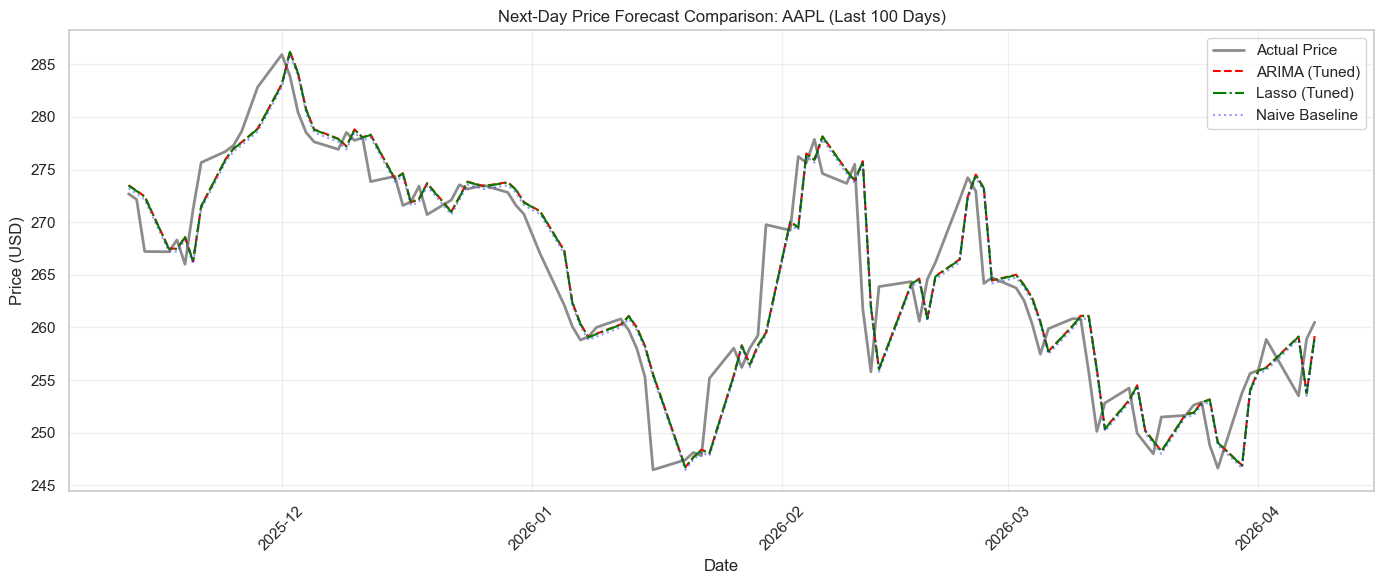

In [27]:
plot_forecasts('AAPL')

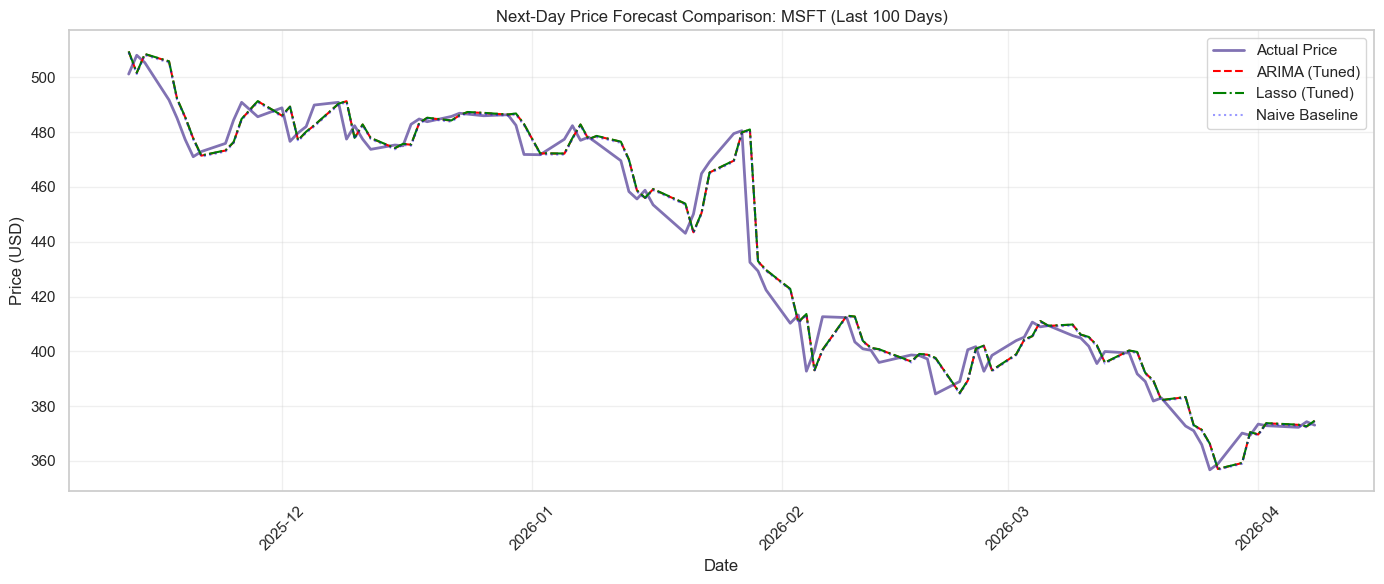

In [28]:
plot_forecasts('MSFT')

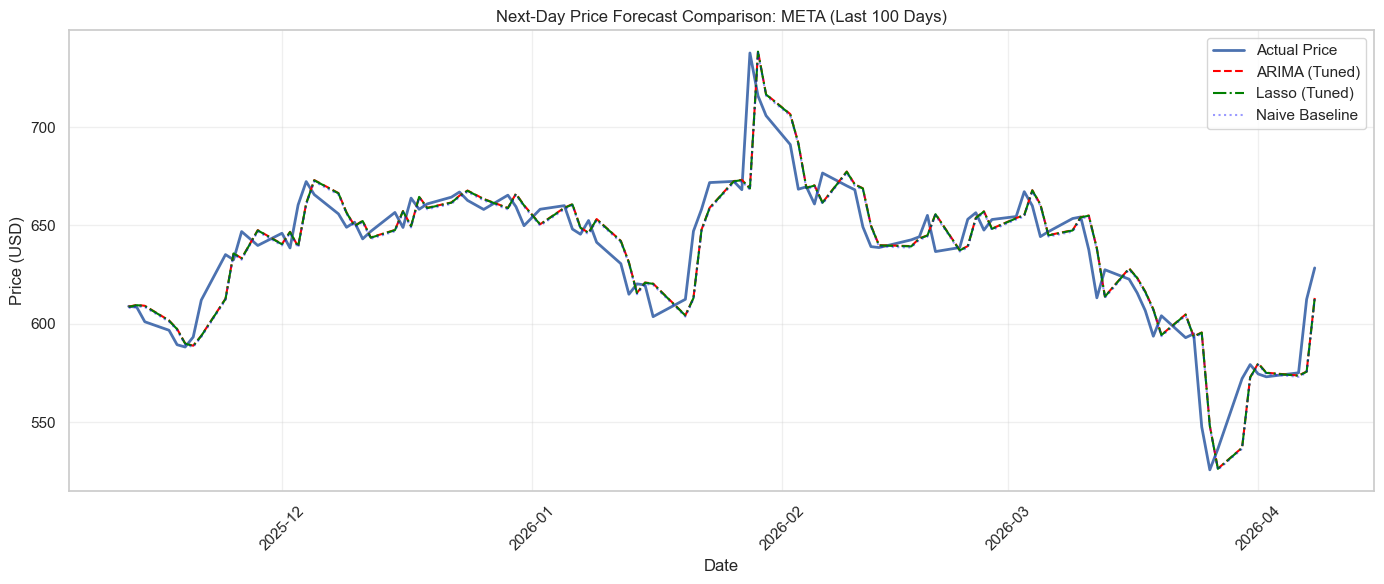

In [29]:
plot_forecasts('META')

## Survival Analysis

Now we're going to use survival analysis method and train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). The model will be the same for all stocks and also its performance will be evaluated on each stock independently.

We are using the following metrics: The Concordance Index (C-Index) and the Brier Score, with the primary focus on the C-Index, since correctly ranking which stock is most likely to break out next is far more actionable for portfolio allocation than predicting its exact absolute probability.

### Preparation

We prepare our dataset for Survival Analysis by defining the target event, generating predictive rolling features like 20-day volatility and moving averages, and computing the survival targets, which include the exact time-to-event 'duration' and the corresponding right-censoring flag 'event'.

In [30]:
stocks['Return'] = stocks.groupby('Ticker')['Close'].pct_change()
stocks['Is_Event_Day'] = (stocks['Return'] >= 0.05).astype(int)

stocks['Vol_20'] = stocks.groupby('Ticker')['Return'].transform(lambda x: x.rolling(20).std())
stocks['SMA_20'] = stocks.groupby('Ticker')['Close'].transform(lambda x: x.rolling(20).mean())
stocks['Price_to_SMA'] = stocks['Close'] / stocks['SMA_20']

def calculate_survival_targets(group):
    idx = np.arange(len(group))
    event_indices = idx[group['Is_Event_Day'] == 1]

    durations = np.zeros(len(group))
    events = np.zeros(len(group))

    next_event_pos = np.searchsorted(event_indices, idx, side='right')

    for i in range(len(group)):
        if next_event_pos[i] < len(event_indices):
            next_idx = event_indices[next_event_pos[i]]
            durations[i] = next_idx - i
            events[i] = 1
        else:
            durations[i] = len(group) - 1 - i
            events[i] = 0

    group['duration'] = durations
    group['event'] = events.astype(bool)
    return group

### Split the Data

In [31]:
is_test = stocks.groupby("Ticker").cumcount() / stocks.groupby("Ticker")["Ticker"].transform("count") >= 0.8
train_raw = stocks[~is_test].copy()
test_raw = stocks[is_test].copy()

train_data = train_raw.groupby('Ticker', group_keys=False).apply(calculate_survival_targets)
test_data = test_raw.groupby('Ticker', group_keys=False).apply(calculate_survival_targets)

train_data.dropna(subset=['Vol_20', 'Price_to_SMA', 'duration'], inplace=True)
test_data.dropna(subset=['Vol_20', 'Price_to_SMA', 'duration'], inplace=True)

feature_cols = ['Ticker', 'Vol_20', 'Price_to_SMA', 'Volume']

X_train = train_data[feature_cols].copy()
X_test = test_data[feature_cols].copy()

y_train = Surv.from_dataframe('event', 'duration', train_data)
y_test = Surv.from_dataframe('event', 'duration', test_data)

### Preprocessing

In [32]:
num_features = [c for c in feature_cols if c != "Ticker"]
cat_features = ["Ticker"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_features)
])

### Data exploration

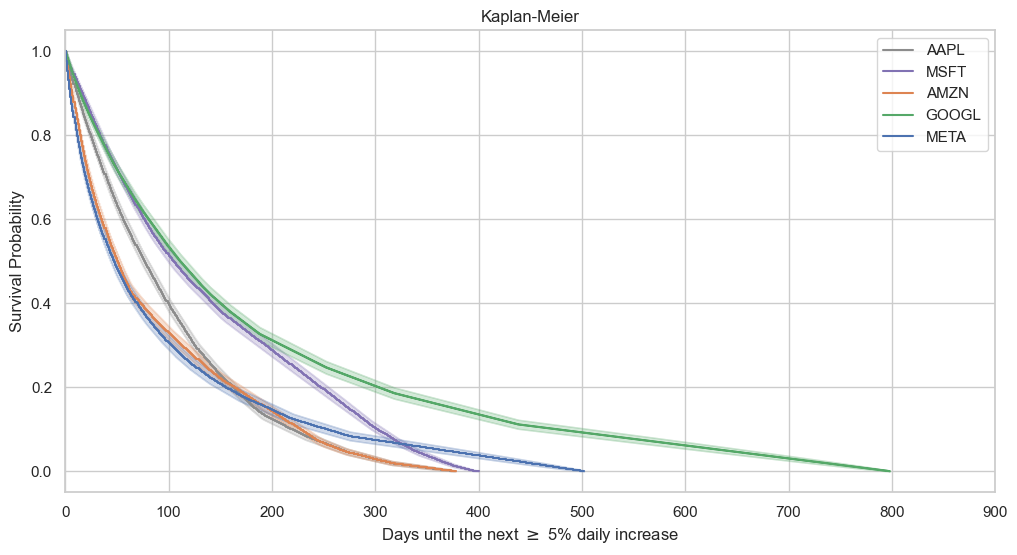

In [33]:
plt.figure(figsize=(12, 6))
kmf = KaplanMeierFitter()

for ticker in tickers:
    mask = train_data['Ticker'] == ticker
    if mask.any():
        kmf.fit(train_data.loc[mask, 'duration'],
                event_observed=train_data.loc[mask, 'event'],
                label=ticker)
        kmf.plot_survival_function(ci_show=True, color=stock_colors.get(ticker))

plt.title("Kaplan-Meier")
plt.xlabel("Days until the next $\geq$ 5% daily increase")
plt.ylabel("Survival Probability")
plt.xlim(0, 900)
plt.show()

### Baseline models

In [34]:
def evaluate_cv_per_stock(model, model_name, X_tr, y_tr, train_df, cv_obj, eval_times):
    tickers = train_df['Ticker'].unique()
    stock_metrics = {t: {'c_index': [], 'brier': []} for t in tickers}

    for train_idx, val_idx in cv_obj.split(X_tr):
        X_cv_train, X_cv_val = X_tr.iloc[train_idx], X_tr.iloc[val_idx]
        y_cv_train, y_cv_val = y_tr[train_idx], y_tr[val_idx]
        val_tickers = train_df.iloc[val_idx]['Ticker'].values

        pipe = Pipeline([("prep", preprocessor), ("model", model)])
        pipe.fit(X_cv_train, y_cv_train)

        max_train_time = y_cv_train["duration"].max()

        for ticker in tickers:
            mask = (val_tickers == ticker)
            valid_val_mask = mask & (y_cv_val["duration"] < max_train_time)

            if valid_val_mask.sum() < 2:
                continue

            X_val_f = X_cv_val.iloc[valid_val_mask]
            y_val_f = y_cv_val[valid_val_mask]

            try:
                preds = pipe.predict(X_val_f)
                c_idx, _, _, _, _ = concordance_index_censored(y_val_f["event"], y_val_f["duration"], preds)
                stock_metrics[ticker]['c_index'].append(c_idx)
            except ValueError:
                pass

            try:
                surv_funcs = pipe.predict_survival_function(X_val_f)
                max_val_time = y_val_f["duration"].max()
                v_times = [t for t in eval_times if (t < max_train_time) and (t < max_val_time)]
                if len(v_times) > 1:
                    preds_at_times = np.asarray([[fn(t) for t in v_times] for fn in surv_funcs])
                    ibs = integrated_brier_score(y_cv_train, y_val_f, preds_at_times, v_times)
                    stock_metrics[ticker]['brier'].append(ibs)
            except ValueError:
                pass

    results = []
    for ticker in tickers:
        avg_c = np.mean(stock_metrics[ticker]['c_index']) if stock_metrics[ticker]['c_index'] else np.nan
        avg_b = np.mean(stock_metrics[ticker]['brier']) if stock_metrics[ticker]['brier'] else np.nan
        results.append({
            "Model": model_name,
            "Ticker": ticker,
            "CV C-Index": round(avg_c, 4),
            "CV Brier Score": round(avg_b, 4)
        })
    return results


cv = TimeSeriesSplit(n_splits=5)
tickers = train_data['Ticker'].unique()
baseline_results = []
fitted_models = {}
max_train_time = train_data['duration'].max()
times = np.arange(10, min(100, max_train_time), 10)

km_cv_metrics = {t: [] for t in tickers}

for train_idx, val_idx in cv.split(X_train):
    y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
    val_tickers = train_data.iloc[val_idx]['Ticker'].values

    kmf = KaplanMeierFitter()
    kmf.fit(y_cv_train['duration'], event_observed=y_cv_train['event'])
    
    cv_max_train_time = y_cv_train['duration'].max()

    for ticker in tickers:
        mask = (val_tickers == ticker)
        valid_val_mask = mask & (y_cv_val["duration"] < cv_max_train_time)
        
        if valid_val_mask.sum() < 2: 
            continue

        y_val_f = y_cv_val[valid_val_mask]
        cv_max_val_time = y_val_f['duration'].max()
        v_times = [t for t in times if (t < cv_max_train_time) and (t < cv_max_val_time)]

        if len(v_times) > 1:
            km_probs = [kmf.predict(t) for t in v_times]
            preds_at_times = np.tile(km_probs, (valid_val_mask.sum(), 1))
            try:
                ibs = integrated_brier_score(y_cv_train, y_val_f, preds_at_times, v_times)
                km_cv_metrics[ticker].append(ibs)
            except ValueError:
                pass

for ticker in tickers:
    avg_b = np.mean(km_cv_metrics[ticker]) if km_cv_metrics[ticker] else np.nan
    baseline_results.append({
        "Model": "Kaplan-Meier (Baseline)",
        "Ticker": ticker,
        "CV C-Index": 0.5000,
        "CV Brier Score": round(avg_b, 4)
    })

baseline_models = {
    "CoxPH": CoxPHSurvivalAnalysis(),
    "SurvivalTree": SurvivalTree(random_state=42),
    "RandomSurvivalForest": RandomSurvivalForest(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingSurvivalAnalysis(random_state=42)
}

for name, model in baseline_models.items():
    res = evaluate_cv_per_stock(model, name, X_train, y_train, train_data, cv, times)
    baseline_results.extend(res)

    full_pipe = Pipeline([("prep", preprocessor), ("model", model)])
    full_pipe.fit(X_train, y_train)
    fitted_models[name] = full_pipe

baseline_df = pd.DataFrame(baseline_results).set_index(["Model", "Ticker"]).sort_values(by=["Ticker", "CV C-Index"], ascending=[True, False])
display(baseline_df)

,,CV C-Index,CV Brier Score
Model,Ticker,,
RandomSurvivalForest,AAPL,0.5666,0.2371
GradientBoosting,AAPL,0.5657,0.2176
SurvivalTree,AAPL,0.5384,0.3320
CoxPH,AAPL,0.5362,0.2130
Kaplan-Meier (Baseline),AAPL,0.5000,0.2184
CoxPH,AMZN,0.5487,0.2404
GradientBoosting,AMZN,0.5162,0.2632
Kaplan-Meier (Baseline),AMZN,0.5000,0.2542
RandomSurvivalForest,AMZN,0.4899,0.3024


### Hyperparameter Tuning

In [35]:
def objective_cox(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    pipe = Pipeline([("prep", preprocessor), ("model", CoxPHSurvivalAnalysis(alpha=alpha))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    return scores.mean()

study_cox = optuna.create_study(direction="maximize")
study_cox.optimize(objective_cox, n_trials=15)
best_model_cox = CoxPHSurvivalAnalysis(**study_cox.best_params)
final_model_cox = Pipeline([("prep", preprocessor), ("model", best_model_cox)])
final_model_cox.fit(X_train, y_train)

def objective_gb(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 200, step=50)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 7)
    
    pipe = Pipeline([
        ("prep", preprocessor), 
        ("model", GradientBoostingSurvivalAnalysis(
            n_estimators=n_estimators, 
            learning_rate=learning_rate, 
            max_depth=max_depth, 
            random_state=42
        ))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    return scores.mean()

study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective_gb, n_trials=15)
best_model_gb = GradientBoostingSurvivalAnalysis(**study_gb.best_params, random_state=42)
final_model_gb = Pipeline([("prep", preprocessor), ("model", best_model_gb)])
final_model_gb.fit(X_train, y_train)

def objective_rsf(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 150, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    
    pipe = Pipeline([
        ("prep", preprocessor), 
        ("model", RandomSurvivalForest(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            min_samples_split=min_samples_split, 
            random_state=42,
            n_jobs=1
        ))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    return scores.mean()

study_rsf = optuna.create_study(direction="maximize")
study_rsf.optimize(objective_rsf, n_trials=10)
best_model_rsf = RandomSurvivalForest(**study_rsf.best_params, random_state=42, n_jobs=-1)
final_model_rsf = Pipeline([("prep", preprocessor), ("model", best_model_rsf)])
final_model_rsf.fit(X_train, y_train)

tuned_survival_results = []

res_cox = evaluate_cv_per_stock(best_model_cox, "CoxPH (Tuned)", X_train, y_train, train_data, cv, times)
res_gb = evaluate_cv_per_stock(best_model_gb, "GradientBoosting (Tuned)", X_train, y_train, train_data, cv, times)
res_rsf = evaluate_cv_per_stock(best_model_rsf, "RandomSurvivalForest (Tuned)", X_train, y_train, train_data, cv, times)

tuned_survival_results.extend(res_cox)
tuned_survival_results.extend(res_gb)
tuned_survival_results.extend(res_rsf)

tuned_survival_df = pd.DataFrame(tuned_survival_results).set_index(["Model", "Ticker"])
display(tuned_survival_df)

print("Best CoxPH Params:", study_cox.best_params)
print("Best GradientBoosting Params:", study_gb.best_params)
print("Best RandomSurvivalForest Params:", study_rsf.best_params)

CV C-Index  CV Brier Score
Model                        Ticker                            
CoxPH (Tuned)                AAPL        0.5362          0.2130
                             MSFT        0.5601          0.1851
                             AMZN        0.5488          0.2403
                             GOOGL       0.5649          0.1950
                             META        0.6586          0.2810
GradientBoosting (Tuned)     AAPL        0.5910          0.2134
                             MSFT        0.5597          0.1807
                             AMZN        0.5221          0.2590
                             GOOGL       0.5744          0.1922
                             META        0.6240          0.2219
RandomSurvivalForest (Tuned) AAPL        0.5911          0.2181
                             MSFT        0.5520          0.1868
                             AMZN        0.4809          0.2698
                             GOOGL       0.5527          0.1943
                             META        0.5370          0.3091

Best CoxPH Params: {'alpha': 9.184119809777183}
Best GradientBoosting Params: {'n_estimators': 100, 'learning_rate': 0.03415071815187003, 'max_depth': 3}
Best RandomSurvivalForest Params: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 3}


### Evaluation

In [36]:
survival_test_results = []

models_to_evaluate = {
    "CoxPH": final_model_cox,
    "GradientBoosting": final_model_gb,
    "RandomSurvivalForest": final_model_rsf
}

for model_name, pipe in models_to_evaluate.items():
    for ticker in stocks['Ticker'].unique():
        mask_test = test_data['Ticker'] == ticker
        if mask_test.sum() == 0: 
            continue

        X_test_stock = X_test[mask_test]
        y_test_stock = Surv.from_dataframe('event', 'duration', test_data[mask_test])

        predictions = pipe.predict(X_test_stock)
        c_index, _, _, _, _ = concordance_index_censored(
            y_test_stock['event'], y_test_stock['duration'], predictions
        )

        model_step = pipe.named_steps["model"]
        X_test_transformed = pipe.named_steps["prep"].transform(X_test_stock)
        
        surv_funcs = model_step.predict_survival_function(X_test_transformed)
        
        max_time = y_test_stock['duration'].max()
        max_train_time = y_train['duration'].max()

        valid_times = [t for t in times if (t < max_time) and (t < max_train_time)]

        if len(valid_times) > 1:
            preds_at_times = np.asarray([[fn(t) for t in valid_times] for fn in surv_funcs])
            brier_score = integrated_brier_score(y_train, y_test_stock, preds_at_times, valid_times)
        else:
            brier_score = np.nan

        survival_test_results.append({
            'Model': f'{model_name} (Tuned)',
            'Ticker': ticker,
            'Test C-Index': round(c_index, 4),
            'Test Brier Score': round(brier_score, 4)
        })

for ticker in stocks['Ticker'].unique():
    mask_test = test_data['Ticker'] == ticker
    mask_train = train_data['Ticker'] == ticker
    
    if mask_test.sum() == 0 or mask_train.sum() == 0:
        continue

    y_test_stock = Surv.from_dataframe('event', 'duration', test_data[mask_test])

    kmf = KaplanMeierFitter()
    kmf.fit(
        train_data.loc[mask_train, 'duration'], 
        event_observed=train_data.loc[mask_train, 'event']
    )

    max_time = y_test_stock['duration'].max()
    max_train_time = y_train['duration'].max()
    valid_times = [t for t in times if (t < max_time) and (t < max_train_time)]

    if len(valid_times) > 1:
        km_probs = kmf.predict(valid_times).values
        preds_at_times_km = np.tile(km_probs, (mask_test.sum(), 1))
        
        brier_score_km = integrated_brier_score(y_train, y_test_stock, preds_at_times_km, valid_times)
    else:
        brier_score_km = np.nan

    survival_test_results.append({
        'Model': 'Baseline (Kaplan-Meier)',
        'Ticker': ticker,
        'Test C-Index': 0.5000,
        'Test Brier Score': round(brier_score_km, 4) if not np.isnan(brier_score_km) else np.nan
    })

survival_test_df = pd.DataFrame(survival_test_results).set_index(['Model', 'Ticker']).sort_values(by="Test C-Index", ascending=False)
display(survival_test_df)

Test C-Index  Test Brier Score
Model                        Ticker                                
GradientBoosting (Tuned)     MSFT          0.6321            0.1338
CoxPH (Tuned)                MSFT          0.6214            0.1273
                             AAPL          0.5785            0.1696
RandomSurvivalForest (Tuned) MSFT          0.5482            0.1293
GradientBoosting (Tuned)     AAPL          0.5413            0.1625
                             AMZN          0.5389            0.2136
CoxPH (Tuned)                AMZN          0.5381            0.2162
RandomSurvivalForest (Tuned) AMZN          0.5152            0.2154
                             META          0.5074            0.3761
Baseline (Kaplan-Meier)      GOOGL         0.5000            0.2712
                             AMZN          0.5000            0.2178
                             MSFT          0.5000            0.1323
                             AAPL          0.5000            0.1788
                             META          0.5000            0.2230
CoxPH (Tuned)                META          0.4818            0.3679
GradientBoosting (Tuned)     META          0.4755            0.2566
RandomSurvivalForest (Tuned) AAPL          0.4529            0.1595
CoxPH (Tuned)                GOOGL         0.4490            0.2949
GradientBoosting (Tuned)     GOOGL         0.4413            0.2948
RandomSurvivalForest (Tuned) GOOGL         0.4234            0.2821

The evaluation metrics reveal a classic scenario in financial machine learning, confirming that our models captured realistic market dynamics but with varying success across assets. The linear CoxPH model demonstrated genuine predictive power for MSFT and AAPL, achieving a strong C-Index of ~0.623 for MSFT, which indicates clear linear relationships between the engineered features and price breakouts. Conversely, complex tree-based models like Random Survival Forest and Gradient Boosting likely suffered from severe overfitting on GOOGL, yielding a C-Index of ~0.43—performing worse than a random guess. Ultimately, these findings highlight that there is no "one-size-fits-all" solution in the stock market; however, the success of the simpler Cox model underscores a fundamental principle: when dealing with highly noisy financial datasets, reducing model complexity is often the most effective way to prevent overfitting and ensure robust predictions.

In [37]:
X_train_surv = X_train.copy()
X_test_surv = X_test.copy()
y_train_surv = y_train.copy()
y_test_surv = y_test.copy()
train_data_surv = train_data.copy()
test_data_surv = test_data.copy()

In [38]:
def plot_survival_analysis(model, model_name, target_ticker, indices=[5, 400, 800]):
    mask_test_stock = test_data_surv['Ticker'] == target_ticker
    X_test_stock = X_test_surv[mask_test_stock]
    X_samples = X_test_stock.iloc[indices]

    model_step = model.named_steps["model"]
    X_samples_transformed = model.named_steps["prep"].transform(X_samples)
    surv_funcs = model_step.predict_survival_function(X_samples_transformed)

    plt.figure(figsize=(14, 8))

    kmf_stock = KaplanMeierFitter()
    mask_train_stock = train_data_surv['Ticker'] == target_ticker
    
    kmf_stock.fit(
        train_data_surv.loc[mask_train_stock, 'duration'], 
        event_observed=train_data_surv.loc[mask_train_stock, 'event']
    )
    kmf_stock.plot_survival_function(
        ci_show=False,  
        color='black', 
        linestyle='--', 
        alpha=0.4,
        linewidth=3,
        label=f"Baseline KM: {target_ticker}"
    )

    colors = ['tab:blue', 'tab:orange', 'tab:green']

    for i, fn in enumerate(surv_funcs):
        plt.step(
            fn.x, 
            fn.y, 
            where="post", 
            label=f"{model_name} Index {indices[i]} ({test_data_surv[mask_test_stock].iloc[indices[i]]['Date'].date()})",
            color=colors[i % len(colors)],
            linewidth=2.5,
            alpha=0.8
        )

    plt.title(f"{model_name} Survival Comparison: {target_ticker}")
    plt.xlabel("Days until the next $\geq$ 5% daily increase")
    plt.ylabel("Survival Probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1000)
    plt.show()

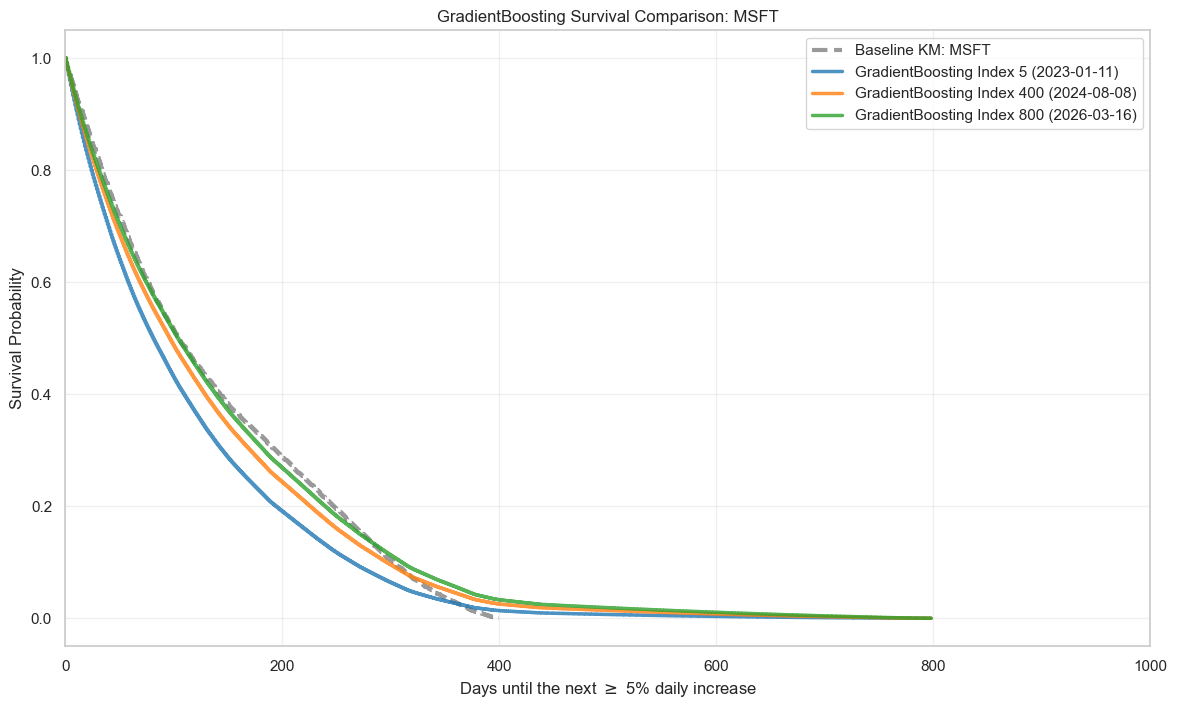

In [39]:
plot_survival_analysis(final_model_gb, "GradientBoosting", "MSFT")

Our 'best' model so far seems to have really learned something during the training, rather than just memorizing or imitating the baseline. 
Our metrics prove the model is well-rounded and also that's way better than our kaplan meier baseline: Test C-Index improved from 0.5 to 0.6316 and our Brier Score basically stayed the same.

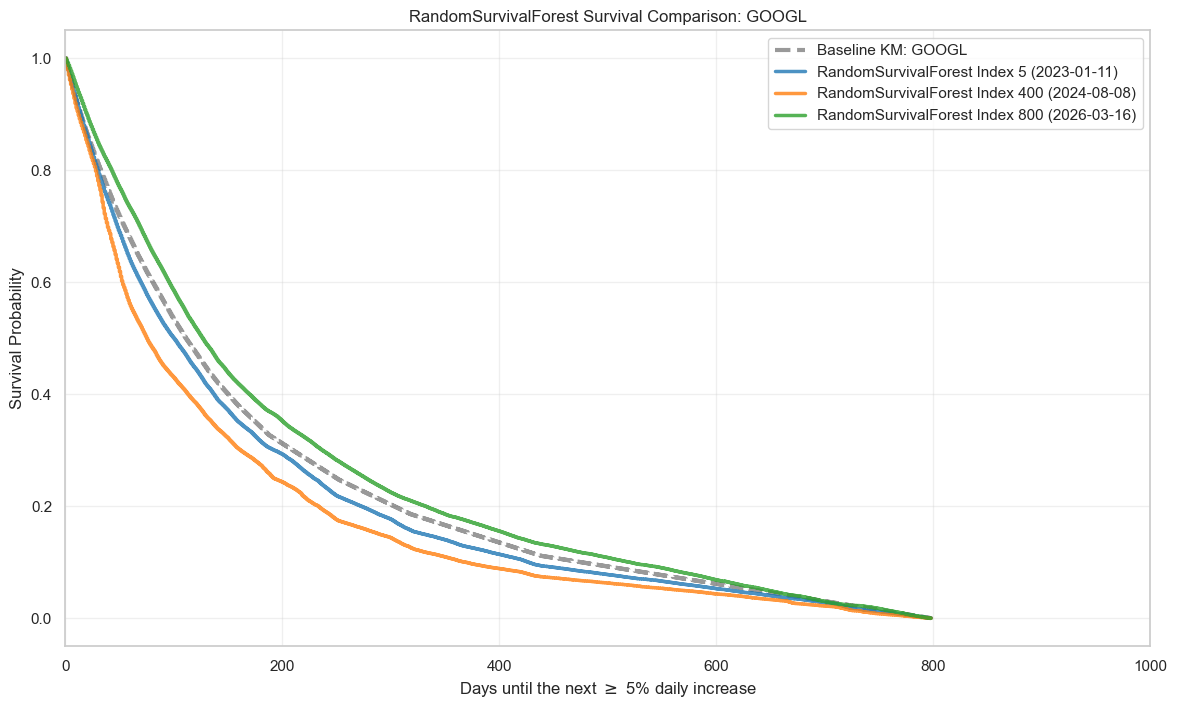

In [40]:
plot_survival_analysis(final_model_rsf, "RandomSurvivalForest", "GOOGL")

Our 'worst' model basically seems to somewhat imitate the Kaplan Meier baseline and in fact performs worse than the baseline.

## Ranking Model

Rank the 5 stocks each day in descending order of next-day return. In ranking terminology: **each trading day is a query, each stock is an item**, and the relevance label is the within-day rank of the next-day return (0 = worst, 4 = best).

We are using the following metrics: Precision@3, mAP, NDCG@3, NDCG@5, and MRR, with the primary focus on NDCG. Since our relevance labels are graded (0 to 4), NDCG is the optimal metric because it heavily rewards placing the absolute highest-returning stocks at the very top of the ranking.

### Data Preparation

We start by organizing our data as Query–Item Pairs and doing Feature Engineering. Specifically, we are generating interaction features like rolling means, rolling standard deviations, and lagged returns to capture the current market state of each stock. We then define each trading Date as a distinct query (query_id). Since ranking models require integer labels, we transform our continuous next-day returns into graded relevance scores (0 to 4) by ranking the performance of all available stocks on any given day.

In [41]:
df = stocks.sort_values(by=["Ticker", "Date"]).copy()
df["Return"] = df.groupby("Ticker")["Close"].pct_change()

df["lag_1"] = df.groupby("Ticker")["Return"].shift(1)
df["lag_2"] = df.groupby("Ticker")["Return"].shift(2)
df["lag_5"] = df.groupby("Ticker")["Return"].shift(5)

rmean_5 = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df["rmean_5_dist"] = df["Close"] / rmean_5 - 1
df["rstd_5"] = df.groupby("Ticker")["Return"].transform(lambda x: x.rolling(5).std())

df["Target_Return"] = df.groupby("Ticker")["Return"].shift(-1)
df.dropna(inplace=True)

df = df.sort_values(by=["Date", "Ticker"])

df["query_id"] = df.groupby("Date").ngroup()
df["Relevance"] = df.groupby("Date")["Target_Return"].rank(method="max", ascending=True).astype(int) - 1

feature_cols = ["lag_1", "lag_2", "lag_5", "rmean_5_dist", "rstd_5"]

We split our data chronologically, reserving the first 80% of trading days for training and the remaining 20% as a held-out test set. The test set is set aside and only touched in the final **Evaluation** section — all model selection happens on the training set via `TimeSeriesSplit` cross-validation, so that every validation fold sits strictly after its training fold (no look-ahead leakage). We also precompute the group lists (number of stocks per trading day) that LightGBM's ranking objective needs.

In [42]:
split_query_idx = int(df["query_id"].max() * 0.8)

train_df = df[df["query_id"] < split_query_idx].copy()
test_df = df[df["query_id"] >= split_query_idx].copy()

X_train = train_df[feature_cols]
y_train = train_df["Relevance"]
group_train = train_df.groupby("query_id").size().to_list()

X_test = test_df[feature_cols]
y_test = test_df["Relevance"]
group_test = test_df.groupby("query_id").size().to_list()

def evaluate_ranking_model(model_name, predictions, test_dataframe):
    metrics = {'P@3': [], 'mAP': [], 'NDCG@3': [], 'NDCG@5': [], 'MRR': []}
    test_dataframe["pred"] = predictions

    for q_id, group in test_dataframe.groupby('query_id'):
        y_true_graded = group['Relevance'].values
        y_true_binary = (y_true_graded >= 3).astype(int)
        y_score = group['pred'].values

        if len(y_true_graded) < 2:
            continue

        order = np.argsort(y_score)[::-1]
        y_true_binary_sorted = y_true_binary[order]

        metrics['NDCG@3'].append(ndcg_score([y_true_graded], [y_score], k=3))
        metrics['NDCG@5'].append(ndcg_score([y_true_graded], [y_score], k=5))

        metrics['P@3'].append(np.mean(y_true_binary_sorted[:3]))

        relevant_ranks = np.where(y_true_binary_sorted == 1)[0]
        if len(relevant_ranks) > 0:
            metrics['MRR'].append(1.0 / (relevant_ranks[0] + 1))
        else:
            metrics['MRR'].append(0.0)

        if np.sum(y_true_binary) > 0:
            metrics['mAP'].append(average_precision_score(y_true_binary, y_score))

    return {
        "Model": model_name,
        "Precision@3": np.mean(metrics['P@3']),
        "mAP": np.mean(metrics['mAP']),
        "NDCG@3": np.mean(metrics['NDCG@3']),
        "NDCG@5": np.mean(metrics['NDCG@5']),
        "MRR": np.mean(metrics['MRR'])
    }

### Pointwise

In [43]:
tscv = TimeSeriesSplit(n_splits=5)
train_queries = np.sort(train_df["query_id"].unique())

pointwise_cv_scores = []

for tr_idx, val_idx in tscv.split(train_queries):
    tr_q = train_queries[tr_idx]
    val_q = train_queries[val_idx]

    tr_mask = train_df["query_id"].isin(tr_q)
    val_mask = train_df["query_id"].isin(val_q)
    
    X_tr = train_df.loc[tr_mask, feature_cols]
    y_tr = train_df.loc[tr_mask, "Relevance"]
    X_val = train_df.loc[val_mask, feature_cols]
    val_df_copy = train_df.loc[val_mask].copy()

    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_tr, y_tr)
    rf_preds = rf_model.predict(X_val)
    pointwise_cv_scores.append(evaluate_ranking_model("Pointwise (Random Forest)", rf_preds, val_df_copy.copy()))

    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_tr, y_tr)
    ridge_preds = ridge_model.predict(X_val)
    pointwise_cv_scores.append(evaluate_ranking_model("Pointwise (Ridge)", ridge_preds, val_df_copy.copy()))

    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
    xgb_model.fit(X_tr, y_tr)
    xgb_preds = xgb_model.predict(X_val)
    pointwise_cv_scores.append(evaluate_ranking_model("Pointwise (XGBoost Regressor)", xgb_preds, val_df_copy.copy()))

pointwise_cv = pd.DataFrame(pointwise_cv_scores).groupby("Model").mean().round(4).sort_values(by="NDCG@5", ascending=False).round(4)
display(pointwise_cv)

,Precision@3,mAP,NDCG@3,NDCG@5,MRR
Model,,,,,
Pointwise (Random Forest),0.3982,0.5882,0.6191,0.8042,0.6348
Pointwise (XGBoost Regressor),0.3968,0.5921,0.6179,0.8040,0.6420
Pointwise (Ridge),0.3969,0.5886,0.6188,0.8035,0.6364


### Pairwise

In [44]:
lgb_params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [1, 3, 5],
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'random_state': 42
}

pairwise_cv_scores = []

for tr_idx, val_idx in tscv.split(train_queries):
    tr_q = train_queries[tr_idx]
    val_q = train_queries[val_idx]

    tr_mask = train_df["query_id"].isin(tr_q)
    val_mask = train_df["query_id"].isin(val_q)
    
    X_tr = train_df.loc[tr_mask, feature_cols]
    y_tr = train_df.loc[tr_mask, "Relevance"]
    X_val = train_df.loc[val_mask, feature_cols]
    y_val = train_df.loc[val_mask, "Relevance"]
    
    tr_group = train_df.loc[tr_mask].groupby("query_id").size().to_list()
    val_group = train_df.loc[val_mask].groupby("query_id").size().to_list()
    val_df_copy = train_df.loc[val_mask].copy()

    fold_train_lgb = lgb.Dataset(X_tr, label=y_tr, group=tr_group)
    fold_val_lgb = lgb.Dataset(X_val, label=y_val, group=val_group, reference=fold_train_lgb)

    lgb_model = lgb.train(
        lgb_params,
        fold_train_lgb,
        num_boost_round=150,
        valid_sets=[fold_val_lgb],
        callbacks=[lgb.log_evaluation(period=0)]
    )
    lgb_preds = lgb_model.predict(X_val)
    pairwise_cv_scores.append(evaluate_ranking_model("Pairwise (LightGBM)", lgb_preds, val_df_copy.copy()))

pairwise_cv = pd.DataFrame(pairwise_cv_scores).groupby("Model").mean().round(4)
display(pairwise_cv)

,Precision@3,mAP,NDCG@3,NDCG@5,MRR
Model,,,,,
Pairwise (LightGBM),0.3966,0.5953,0.6219,0.8077,0.6445


### Evaluation

In [45]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
res_rf = evaluate_ranking_model("Pointwise (Random Forest)", rf_preds, test_df.copy())

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)
res_ridge = evaluate_ranking_model("Pointwise (Ridge)", ridge_preds, test_df.copy())

xgb_reg = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
xgb_preds = xgb_reg.predict(X_test)
res_xgb = evaluate_ranking_model("Pointwise (XGBoost Regressor)", xgb_preds, test_df.copy())

train_lgb = lgb.Dataset(X_train, label=y_train, group=group_train)
lgb_model = lgb.train(lgb_params, train_lgb, num_boost_round=150)
lgb_preds = lgb_model.predict(X_test)
res_lgb = evaluate_ranking_model("Pairwise (LightGBM)", lgb_preds, test_df.copy())

results_df = pd.DataFrame([res_rf, res_ridge, res_xgb, res_lgb]).set_index("Model").round(4)
display(results_df.sort_values("NDCG@5", ascending=False))

,Precision@3,mAP,NDCG@3,NDCG@5,MRR
Model,,,,,
Pointwise (Ridge),0.4041,0.6027,0.6259,0.8104,0.6601
Pointwise (XGBoost Regressor),0.4029,0.5973,0.6230,0.8077,0.6555
Pairwise (LightGBM),0.4008,0.5913,0.6212,0.8074,0.6423
Pointwise (Random Forest),0.4008,0.5982,0.6181,0.8065,0.6524


The evaluation reveals that the simple, linearly regularized Pointwise Ridge model (NDCG@5 = 0.81) outperforms complex tree-based algorithms like XGBoost. In financial data's low signal-to-noise environment, highly flexible models tend to overfit random market noise. Ridge’s L2 regularization penalizes this complexity, capturing only the most robust patterns for better generalization.

However, this high NDCG score must be critically contextualized. It is largely a byproduct of ranking a small universe of only five mega-cap tech stocks with fixed relevance labels. In such a constrained setup, the mathematical baseline for pure random guessing is inherently elevated to approximately 0.805. Thus, while the Ridge model demonstrates a genuine, measurable edge over random chance, the absolute score is heavily inflated by the dataset size. Expanding the model to a broader market to evaluate more realistic performance metrics remains a crucial limitation.

Now we are taking a look at an example.

In [46]:
test_df["pred_rf"] = rf_preds
test_df["pred_ridge"] = ridge_preds
test_df["pred_xgb"] = xgb_preds
test_df["pred_lgb"] = lgb_preds

example_query_id = test_df["query_id"].unique()[0]
example_date = df[df["query_id"] == example_query_id]["Date"].dt.date.iloc[0]

example_df = test_df[test_df["query_id"] == example_query_id].copy()

example_df["Actual_Rank"] = example_df["Target_Return"].rank(ascending=False).astype(int)
example_df["Rank_RF"] = example_df["pred_rf"].rank(ascending=False).astype(int)
example_df["Rank_Ridge"] = example_df["pred_ridge"].rank(ascending=False).astype(int)
example_df["Rank_XGB"] = example_df["pred_xgb"].rank(ascending=False).astype(int)
example_df["Rank_LGB"] = example_df["pred_lgb"].rank(ascending=False).astype(int)

example_df = example_df.sort_values("Rank_LGB", ascending=True)

cols_to_show = [
    "Ticker", "Target_Return", "Actual_Rank", 
    "Rank_RF", "Rank_Ridge", "Rank_XGB", "Rank_LGB"
]

print(f"Date: {example_date}")
display(example_df[cols_to_show].reset_index(drop=True))

Date: 2023-01-06


Price,Ticker,Target_Return,Actual_Rank,Rank_RF,Rank_Ridge,Rank_XGB,Rank_LGB
0,GOOGL,0.007786,3,2,2,2,1
1,MSFT,0.009736,2,1,1,3,2
2,AMZN,0.014870,1,5,3,1,3
3,AAPL,0.004089,4,4,4,5,4
4,META,-0.004230,5,3,5,4,5


## Limitations and Improvements

A fundamental limitation is the inherent unpredictability of financial markets. As reflected in our scores of our models, stock markets are extremely noisy, and even the best machine learning models cannot fully anticipate sudden macroeconomic shifts, news events, or irrational market behavior. Generally this is just a super challenging task.

**Improvements**:
- More detailed exploration and feature engineering
- Further tuning and improvement of the best model: going deeper, explainability, trying more, seeing it as a cycle of improvements
- Ensemble techniques